In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [2]:
# reading the dataset
df = pd.read_csv("C:/Users/Rizwan/Desktop/dissertation/dataset/Telco_customer_churn.csv")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [5]:
#finding how many rows and columns we have in our dataset
df.shape

(7043, 33)

we have 7043 rows and 33 features

In [6]:
#getting the data types of all columns in our dataset
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### Converting Data type

In [8]:
#when we are trying to convert the object value ['Total charges'] column into float it shows an error that Unable to parse string " " so we need to replace this blank space with Na
blank_values_count = (df['Total Charges'] == ' ').sum()
print("Total Blank Values are: ",blank_values_count)

Total Blank Values are:  11


In [9]:
#replacing blank values with Na
df['Total Charges'] = df['Total Charges'].replace(' ', np.nan)

#converting object into float
df['Total Charges'] = df['Total Charges'].astype(float)

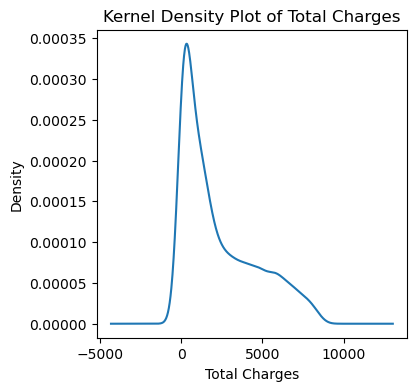

In [10]:
# check the distribution of the data by using kernel density plot

plt.figure(figsize=(4, 4))
df['Total Charges'].plot(kind='kde')
plt.xlabel('Total Charges')
plt.title('Kernel Density Plot of Total Charges')
plt.show()

as we ca see data is skewed so will use median to fill na values 

In [11]:
median_value = df['Total Charges'].median()

# Replacing the NaN values with the median
df['Total Charges'] = df['Total Charges'].fillna(median_value)

In [12]:
# again calculate how many nan we have now
nan_val_count = df['Total Charges'].isna().sum()
print("Number of NaN values in 'Total Charges':", nan_val_count)

Number of NaN values in 'Total Charges': 0


## Data Analysis 

In [13]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2281.916928,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.270398,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


### Finding Columns which has Nan Values 

<Axes: >

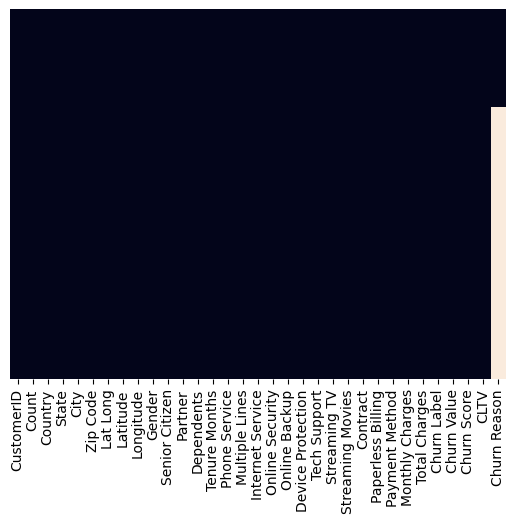

In [14]:
#finding which columns has more Nan Values
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)

It can be seen that churn reason is showing Nan values after a specific rows all the values are Nan rest of all features has zero Nan Values 

In [15]:
#finding how many nan values are in column ['Churn Reason']
df['Churn Reason'].isnull().value_counts()

True     5174
False    1869
Name: Churn Reason, dtype: int64

In [16]:
# making a list of all the nan values which are present in out dataset
na_features = [features for features in df.columns if df[features].isnull().sum()>1]

for features in na_features:
    print(features, np.round(df[features].isnull().mean(),4)*100, '% Missing Values')

Churn Reason 73.46000000000001 % Missing Values


There are in total 5174 rows which are Nan in feature churn Reason It is because the churn value is 0 which means customer is not churned so there must be empty churn reason.

### Finding Numerical Features 

In [17]:
#finding how many numerical columns we have in our dataset
num_columns = [columns for columns in df.columns if df[columns].dtypes != 'O']

print('Number of Numerical Columns: ', len(num_columns))

#getting numerical columns data 
df[num_columns].head()

Number of Numerical Columns:  10


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,1,90003,33.964131,-118.272783,2,53.85,108.15,1,86,3239
1,1,90005,34.059281,-118.307420,2,70.70,151.65,1,67,2701
2,1,90006,34.048013,-118.293953,8,99.65,820.50,1,86,5372
3,1,90010,34.062125,-118.315709,28,104.80,3046.05,1,84,5003
4,1,90015,34.039224,-118.266293,49,103.70,5036.30,1,89,5340


### Finding Categorical Features 

In [18]:
#finding how many categorical columns we have in our dataset
cat_columns=[columns for columns in df.columns if df[columns].dtypes=='O']

print('Number of Categorical Columns: ', len(cat_columns))

#getting Categorical columns data 
df[cat_columns].head()

Number of Categorical Columns:  23


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label,Churn Reason
0,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,Competitor made better offer
1,9237-HQITU,United States,California,Los Angeles,"34.059281, -118.30742",Female,No,No,Yes,Yes,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,Moved
2,9305-CDSKC,United States,California,Los Angeles,"34.048013, -118.293953",Female,No,No,Yes,Yes,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,Yes,Moved
3,7892-POOKP,United States,California,Los Angeles,"34.062125, -118.315709",Female,No,Yes,Yes,Yes,...,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,Yes,Moved
4,0280-XJGEX,United States,California,Los Angeles,"34.039224, -118.266293",Male,No,No,Yes,Yes,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),Yes,Competitor had better devices


out of 33 columns we have 23 categorical columns and 9 numerical columns now lets find out how many unique values we have in each categorical columns 

In [19]:
#finding unique values in categorical columns
for columns in cat_columns:
    print('column {} having number of categories are {}'.format(columns,len(df[columns].unique())))

column CustomerID having number of categories are 7043
column Country having number of categories are 1
column State having number of categories are 1
column City having number of categories are 1129
column Lat Long having number of categories are 1652
column Gender having number of categories are 2
column Senior Citizen having number of categories are 2
column Partner having number of categories are 2
column Dependents having number of categories are 2
column Phone Service having number of categories are 2
column Multiple Lines having number of categories are 3
column Internet Service having number of categories are 3
column Online Security having number of categories are 3
column Online Backup having number of categories are 3
column Device Protection having number of categories are 3
column Tech Support having number of categories are 3
column Streaming TV having number of categories are 3
column Streaming Movies having number of categories are 3
column Contract having number of cat

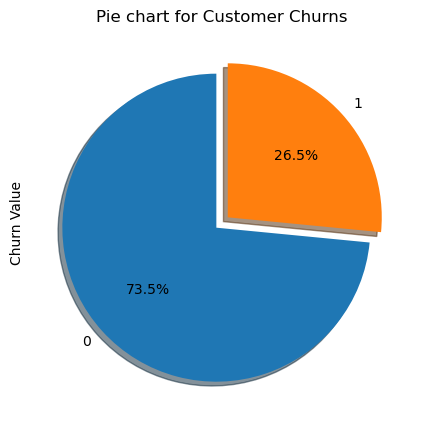

0    5174
1    1869
Name: Churn Value, dtype: int64

In [20]:
# findout how many churns we have in our dataset
df['Churn Value'].value_counts().plot.pie(explode=[0.05,0.05], autopct = '%1.1f%%', startangle=90, shadow=True, figsize=(5,5))
plt.title('Pie chart for Customer Churns')
plt.show()

#total count of churners and non churners
df['Churn Value'].value_counts()

0 means non churners

1 means churners 

So out of 7043 customers 1869 customers are churners now we will analyze what are the main factors of customer churns

### 1) Gender with Churn Value

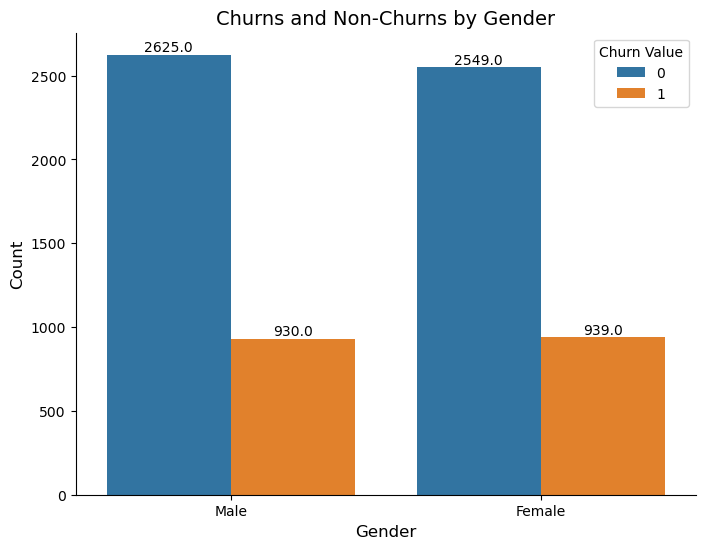

In [21]:
plt.figure(figsize=(8, 6))
gen_count = sns.countplot(data=df, x='Gender', hue='Churn Value')

# adding x and y labels
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Gender', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in gen_count.patches:
    height = count.get_height()
    gen_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()


Out of 3555 males 930 males are experienced as churners on the other hand out of 3488 females 939 are experienced as churners it shows that The churn rates for both males and females are nearly identical

### 2) Senior Citizen with Churn Value

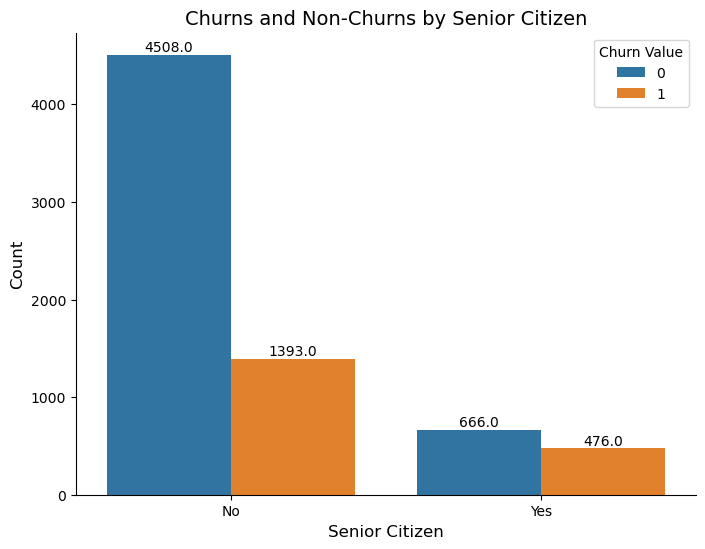

In [22]:
plt.figure(figsize=(8, 6))
sc_count = sns.countplot(data=df, x='Senior Citizen', hue='Churn Value')

# adding x and y labels
plt.xlabel('Senior Citizen', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Senior Citizen', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in sc_count.patches:
    height = count.get_height()
    sc_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 1142 customers who are in category of senior citizen and out of this 476 are churners where as the count of customers who are not in category of senior citizens are 5901 out of this 1393 are churners overall it shows that churn rate of a senior citizen is about 41.7% on the other hand churn rate of a non senior citizen is about 23.6% which is lower than senior citizen rate hence the customers who are senior citizen has the higher churn rate. 

### 3) Partner with Churn Value

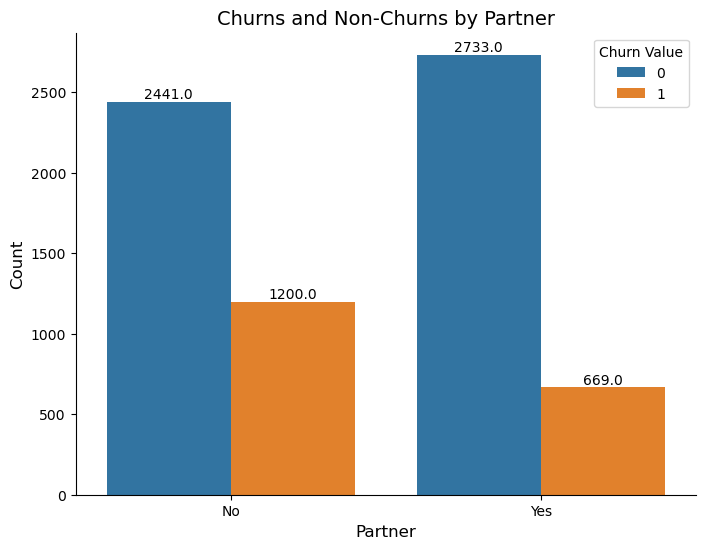

In [23]:
plt.figure(figsize=(8, 6))
partner_count = sns.countplot(data=df, x='Partner', hue='Churn Value')

# adding x and y labels
plt.xlabel('Partner', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Partner', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in partner_count.patches:
    height = count.get_height()
    partner_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 3402 customers who have partner and out of this 669 are churners where as the customers who do not have a partner are 3641 out of this 1200 are churners overall it shows that churn rate of customers who have partner is about 19.7% on the other hand churn rate of a customers who do not have a partner is about 33%. Hence the customer who do not have partners experienced higher churn rate.

### 3) Dependents with Churn Value

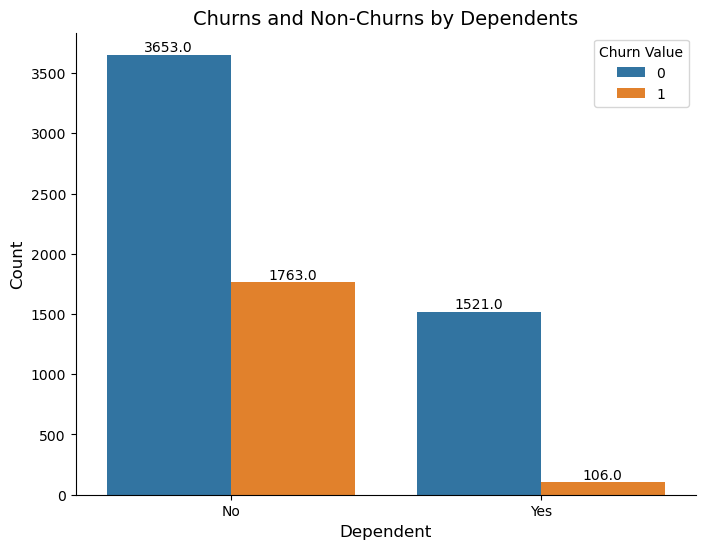

In [24]:
plt.figure(figsize=(8, 6))
dep_count = sns.countplot(data=df, x='Dependents', hue='Churn Value')

# adding x and y labels
plt.xlabel('Dependent', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Dependents', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in dep_count.patches:
    height = count.get_height()
    dep_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 1627 customers who lives with any Dependent and out of this 106 are churners where as the customers who do not have any dependent are 5416 out of this 1763 are churners overall it shows that churn rate of customers who lives with dependent is about 6.5% on the other hand churn rate of a customers who do not live with any dependent is about 32.5%. Hence the customer who do not have any dependent experienced higher churn rate.

### 4) Phone Service with Churn Value

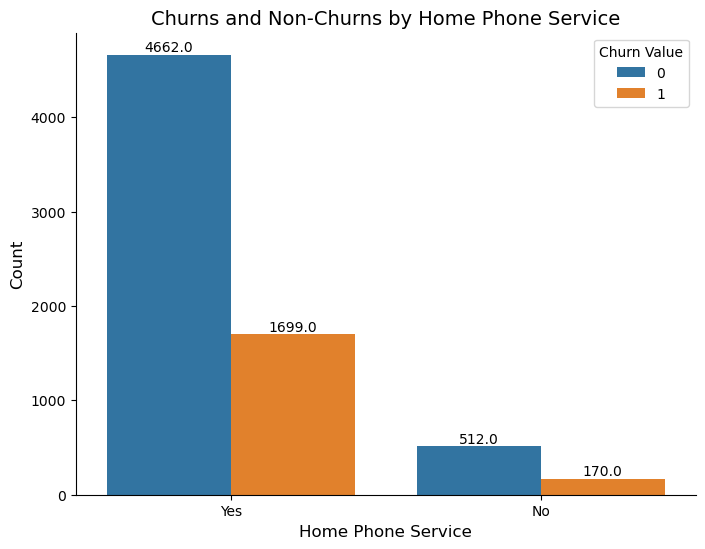

In [25]:
plt.figure(figsize=(8, 6))
phone_ser_count = sns.countplot(data=df, x='Phone Service', hue='Churn Value')

# adding x and y labels
plt.xlabel('Home Phone Service', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Home Phone Service', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in phone_ser_count.patches:
    height = count.get_height()
    phone_ser_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 6361 customers who have chosen the teliphone service for their home (landline service) and out of this 1699 are churners where as the customers who do not have any home phone service are 682 out of this 170 are churners overall it shows that churn rate of customers who have any home phone service is about 26.7% on the other hand churn rate of a customers who do not have any home phone service is about 24.9%. The churn rates indicates that the both customers who have or not have home phone service are quite similar but the customer who are with home phone service experienced slightly higher churn rate.

### 5) Multiple Lines with Churn Value

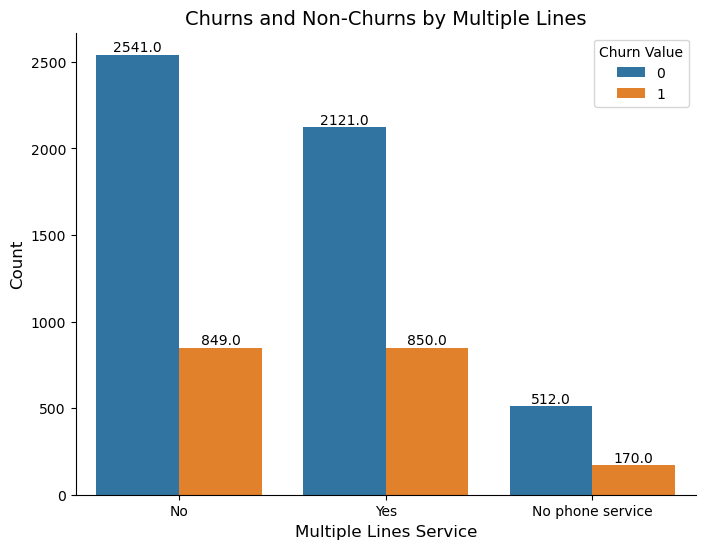

In [26]:
plt.figure(figsize=(8, 6))
mul_lines_count = sns.countplot(data=df, x='Multiple Lines', hue='Churn Value')

# adding x and y labels
plt.xlabel('Multiple Lines Service', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Multiple Lines', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

#showing counts on the top of bar
for count in mul_lines_count.patches:
    height = count.get_height()
    mul_lines_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2971 customers who subscribe to multiple lines with the company and out of this 850 are churners where as the customers who do not subscribe to multiple lines are 3390 out of this 849 are churners and there are 682 customers who does not subscribe for any phone service out of this 170 customers are churners. overall it shows that churn rate of customers who subscribe to multiple lines service is about 28.6% on the other hand churn rate of a customers who does not subscribe for the service is about 25.1%. and the churn rate of customers who does not subscribe for any teliphone service with the company is about 24.9%. The churn rates indicates that the customers who have subscribe for the multiple lines service has the higher churn rate compare to the customers who does not subscribe for multiple line service or any phone service moreover the customers who does not subscribe of the service and does not have phone service their churn rates are relatively similar.

### 6) Internet Service with Churn Value


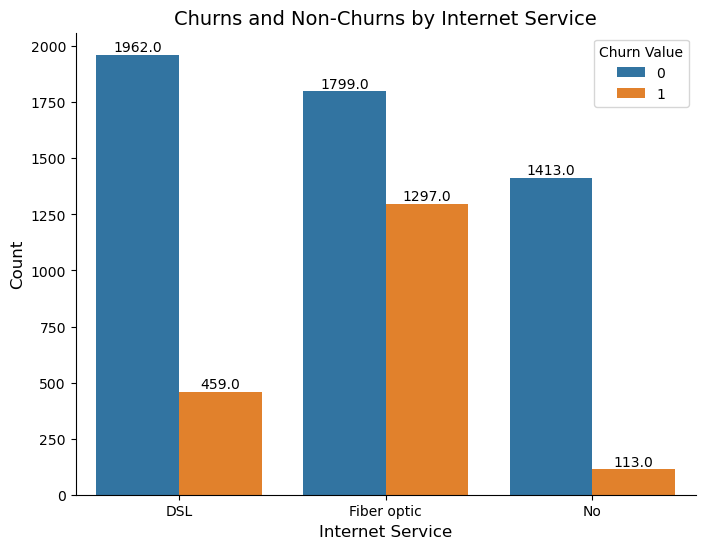

In [27]:
plt.figure(figsize=(8, 6))
internet_serv_count = sns.countplot(data=df, x='Internet Service', hue='Churn Value')

# adding x and y labels
plt.xlabel('Internet Service', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Internet Service', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in internet_serv_count.patches:
    height = count.get_height()
    internet_serv_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2421 customers who subscribe to DSL internet service and out of this 459 are churners where as the customers who subscribe to Fiber optic internet service are 3096 out of this 1297 are churners and there are 1526 customers who does not subscribe for any internet serive out of this 113 customers are churners. overall it shows that churn rate of customers who subscribe to DSL internet service is about 19% on the other hand churn rate of a customers who subscribe to Fiber optic internet service is about 41.9%. and the churn rate of customers who does not subscribe for any internet service with the company is about 7.4%. The churn rates indicates that the customers who subscribe to Fiber Optic internet service has the higher churn rate compare to DSL where as the customers who does not subscribe for any internet service has the lower churn rate. Moreover there are more customer who use Fiber optic internet service

### 7) Online Security with Churn Value


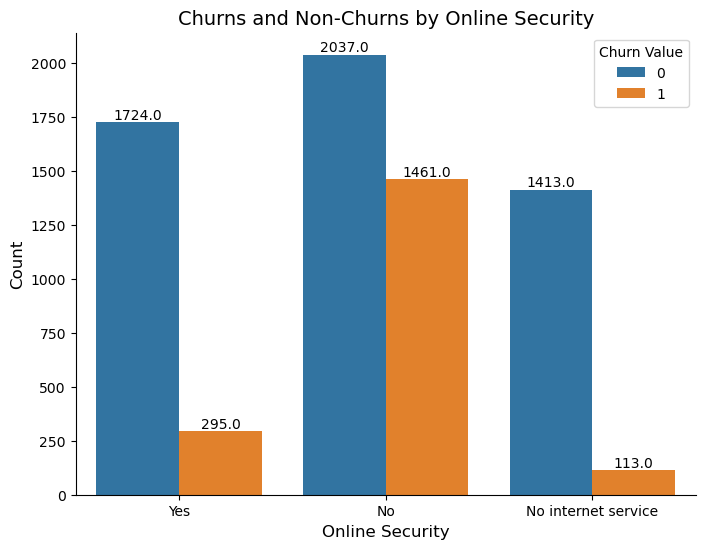

In [28]:
plt.figure(figsize=(8, 6))
online_sec_count = sns.countplot(data=df, x='Online Security', hue='Churn Value')

# adding x and y labels
plt.xlabel('Online Security', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Online Security', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in online_sec_count.patches:
    height = count.get_height()
    online_sec_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2019 customers who subscribe to an additional online security service and out of this 295 are churners where as the customers who does not subscribe to an additional online security service are 3498 out of this 1461 are churners and there are 1526 customers who does not subscribe for any internet serive out of this 113 customers are churners. overall it shows that churn rate of customers who subscribe to an additional online security service is about 14.6% on the other hand churn rate of a customers who who does not subscribe to an additional online security service is about 41.8%. and the churn rate of customers who does not subscribe for any internet service with the company is about 7.4%. hence The churn rates indicates that the customers who does not subscribe to an additional online security service has the higher churn rate compare to the customers subscribe for this online security service.

### 8) Online Backup with Churn Value


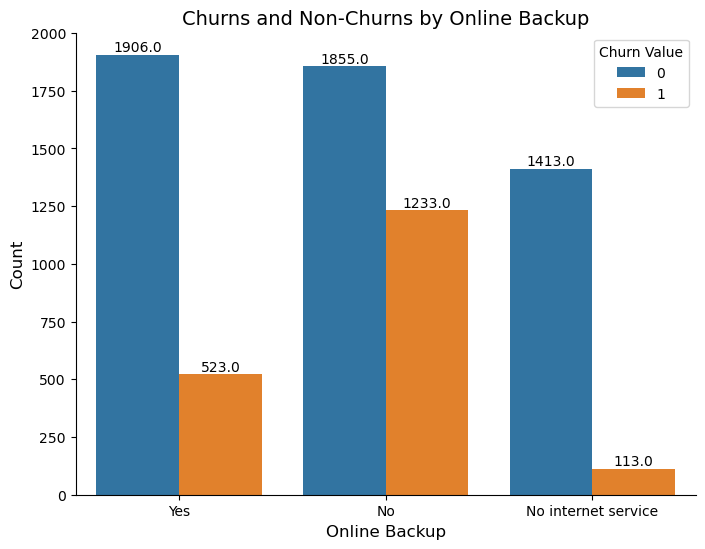

In [29]:
plt.figure(figsize=(8, 6))
online_back_count = sns.countplot(data=df, x='Online Backup', hue='Churn Value')

# adding x and y labels
plt.xlabel('Online Backup', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Online Backup', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in online_back_count.patches:
    height = count.get_height()
    online_back_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2429 customers who subscribe to an additional online backup service and out of this 523 are churners where as the customers who does not subscribe to an additional online backup service are 3088 out of this 1233 are churners and there are 1526 customers who does not subscribe for any internet serive out of this 113 customers are churners. overall it shows that churn rate of customers who subscribe to an additional online backup service is about 21.5% on the other hand churn rate of a customers who who does not subscribe to an additional online backup service is about 39.9%. and the churn rate of customers who does not subscribe for any internet service with the company is about 7.4%. hence The churn rates indicates that the customers who does not subscribe to an additional online backup service has the higher churn rate compare to the customers subscribe for this online backup service.

### 9) Device Protection with Churn Value


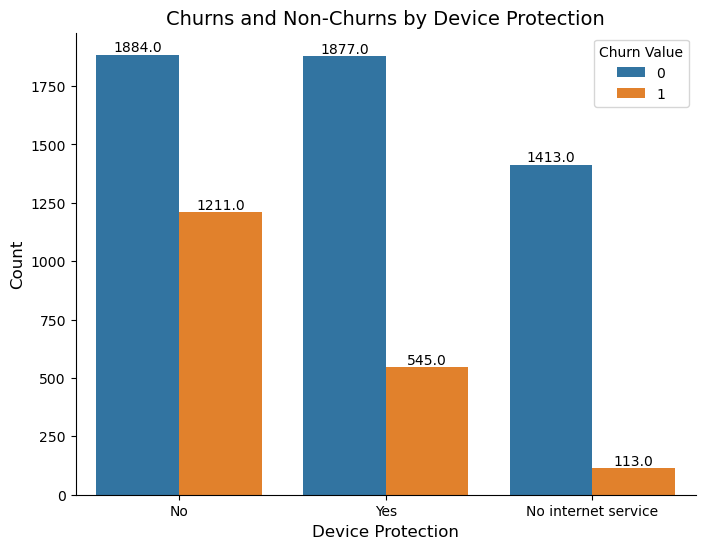

In [30]:
plt.figure(figsize=(8, 6))
device_pro_count = sns.countplot(data=df, x='Device Protection', hue='Churn Value')

# adding x and y labels
plt.xlabel('Device Protection', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Device Protection', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in device_pro_count.patches:
    height = count.get_height()
    device_pro_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2422 customers who subscribe to an additional device protection service and out of this 545 are churners where as the customers who does not subscribe to an additional device protection service are 3095 out of this 1211 are churners and there are 1526 customers who does not subscribe for any internet serive out of this 113 customers are churners. overall it shows that churn rate of customers who subscribe to an additional device protection service is about 22.5% on the other hand churn rate of a customers who who does not subscribe to an additional device protection service service is about 39.1%. and the churn rate of customers who does not subscribe for any internet service with the company is about 7.4%. hence The churn rates indicates that the customers who does not subscribe to an additional device protection service has the higher churn rate compare to the customers subscribe for this device protection service.

### 10) Tech Support with Churn Value


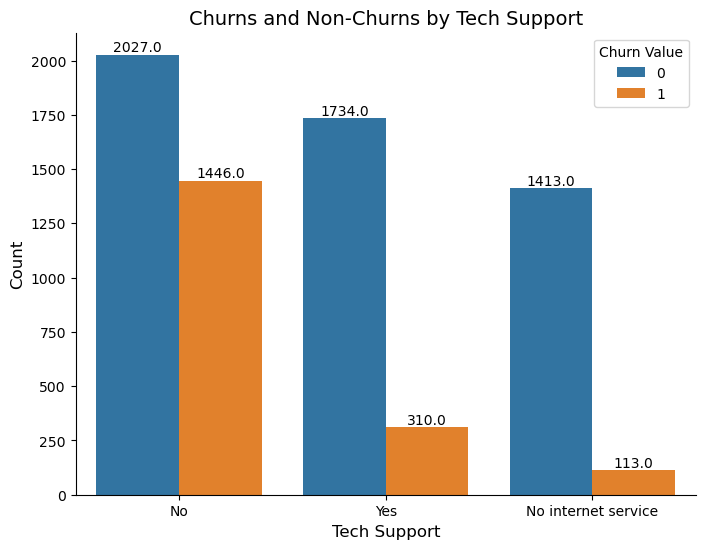

In [31]:
plt.figure(figsize=(8, 6))
tech_sup_count = sns.countplot(data=df, x='Tech Support', hue='Churn Value')

# adding x and y labels
plt.xlabel('Tech Support', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Tech Support', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in tech_sup_count.patches:
    height = count.get_height()
    tech_sup_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2044 customers who subscribe to an additional tech support service to reduce wait time and out of this 310 are churners where as the customers who does not subscribe to an additional tech support service are 3473 out of this 1446 are churners and there are 1526 customers who does not subscribe for any internet serive out of this 113 customers are churners. overall it shows that churn rate of customers who subscribe to an additional tech support service is about 15.2% on the other hand churn rate of a customers who who does not subscribe to an additional tech support service service is about 41.6%. and the churn rate of customers who does not subscribe for any internet service with the company is about 7.4%. hence The churn rates indicates that the customers who does not subscribe to an additional tech support service has the higher churn rate compare to the customers subscribe for this tech support service.

### 11) Streaming TV with Churn Value


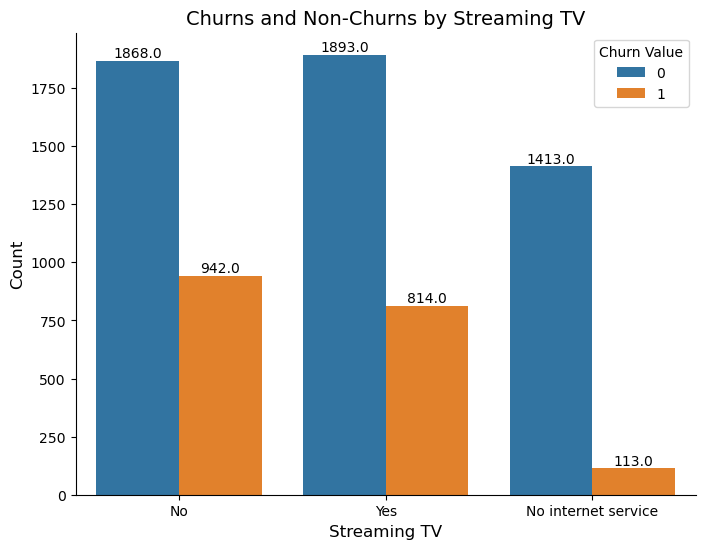

In [32]:
plt.figure(figsize=(8, 6))
stream_tv_count = sns.countplot(data=df, x='Streaming TV', hue='Churn Value')

# adding x and y labels
plt.xlabel('Streaming TV', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Streaming TV', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in stream_tv_count.patches:
    height = count.get_height()
    stream_tv_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2707 customers who use their internet connection to stream telivision program from an external service provider and out of this 814 are churners where as the customers who does not use their streaming TV service are 2810 out of this 942 are churners and there are 1526 customers who does not subscribe for any internet serive out of this 113 customers are churners. overall it shows that churn rate of customers who use their internet connection to stream telivision program is about 30.1% on the other hand churn rate of a customers who who does not use their streaming TV service is about 33.5%. and the churn rate of customers who does not subscribe for any internet service with the company is about 7.4%. hence The churn rates indicates that the customers who does not use their streaming TV service has the higher churn rate it also indicate that the usage of streaming TV slightly reduce the customer churn.

### 12) Streaming Movies with Churn Value


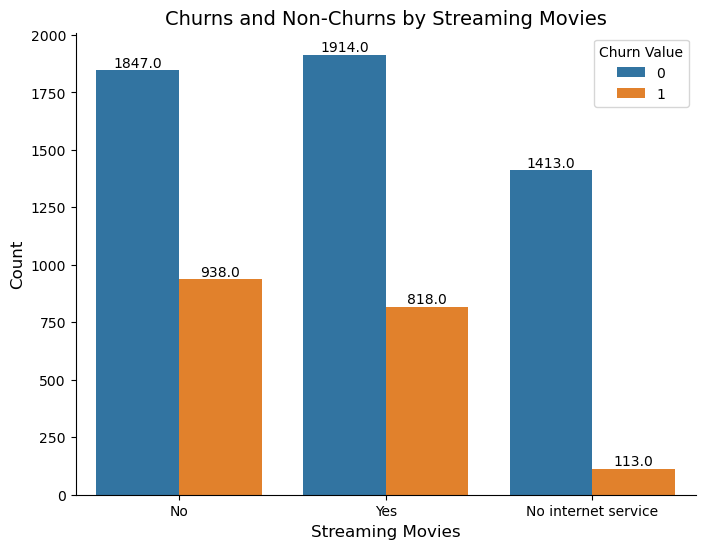

In [33]:
plt.figure(figsize=(8, 6))
stream_mov_count = sns.countplot(data=df, x='Streaming Movies', hue='Churn Value')

# adding x and y labels
plt.xlabel('Streaming Movies', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Streaming Movies', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in stream_mov_count.patches:
    height = count.get_height()
    stream_mov_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 2732 customers who use their internet connection to stream movies from an external service provider and out of this 818 are churners where as the customers who does not use their movie stream service are 2785 out of this 938 are churners and there are 1526 customers who does not subscribe for any internet serive out of this 113 customers are churners. overall it shows that churn rate of customers who use their internet connection to stream movies is about 30% on the other hand churn rate of a customers who who does not use their movie stream service is about 33.7%. and the churn rate of customers who does not subscribe for any internet service with the company is about 7.4%. hence The churn rates indicates that the customers who does not use their movie stream service has the higher churn rate it also indicate that the usage of movie streaming slightly reduce the customer churn.

### 13) Contract with Churn Value


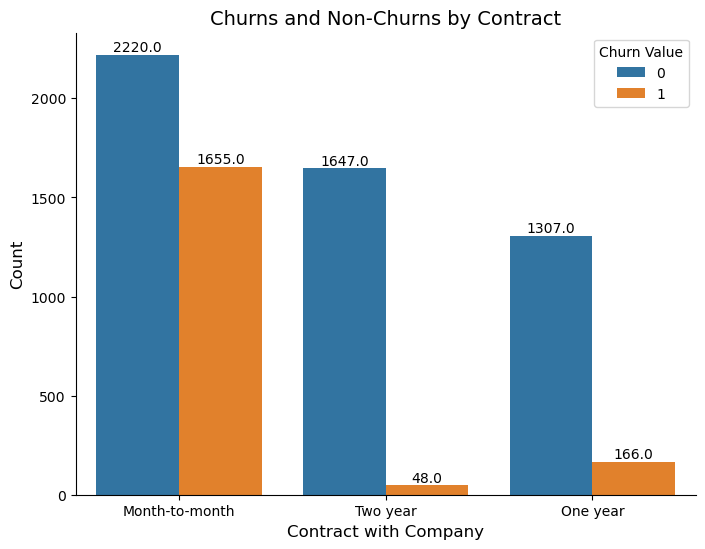

In [34]:
plt.figure(figsize=(8, 6))
contract_count = sns.countplot(data=df, x='Contract', hue='Churn Value')

# adding x and y labels
plt.xlabel('Contract with Company', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Contract', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in contract_count.patches:
    height = count.get_height()
    contract_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 3875 customers who use month to month contract and out of this 1655 are churners where as the customers who use two year contract are 1695 out of this 48 are churners and there are 1473 customers who use one year contract out of this 166 customers are churners. overall it shows that churn rate of customers who use month to month contract is about 42.7% on the other hand churn rate of a customers who use two year contract is about 2.8%. and the churn rate of customers who who use one year contract is about 11.3%. hence The churn rates indicates that the customers who use month to month contract has the higher churn rate it also indicate that the long term contracts help to reduce customer churn.

### 14) Paperless Billing with Churn Value


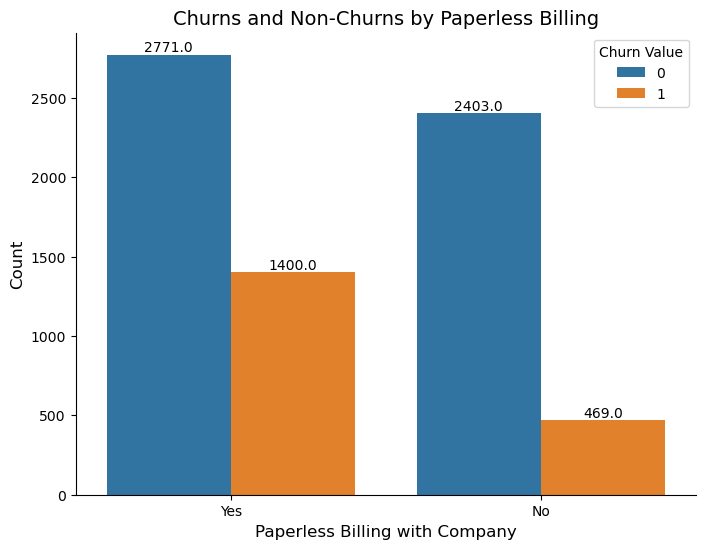

In [35]:
plt.figure(figsize=(8, 6))
paperless_bil_count = sns.countplot(data=df, x='Paperless Billing', hue='Churn Value')

# adding x and y labels
plt.xlabel('Paperless Billing with Company', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Paperless Billing', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in paperless_bil_count.patches:
    height = count.get_height()
    paperless_bil_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 4171 customers who has chosen paperless billing and out of this 1400 are churners where as the customers who has not chosen paperless billing are 2872 out of this 469 are churners overall it shows that churn rate of customers who have chosen paperless billing is about 33.5% on the other hand churn rate of a customers who have not chosen paperless billing is about 16.3%. Hence there are more customers who prefer to use paperless billing but also they experienced higher churn rate.

### 15) Payment Method with Churn Value 


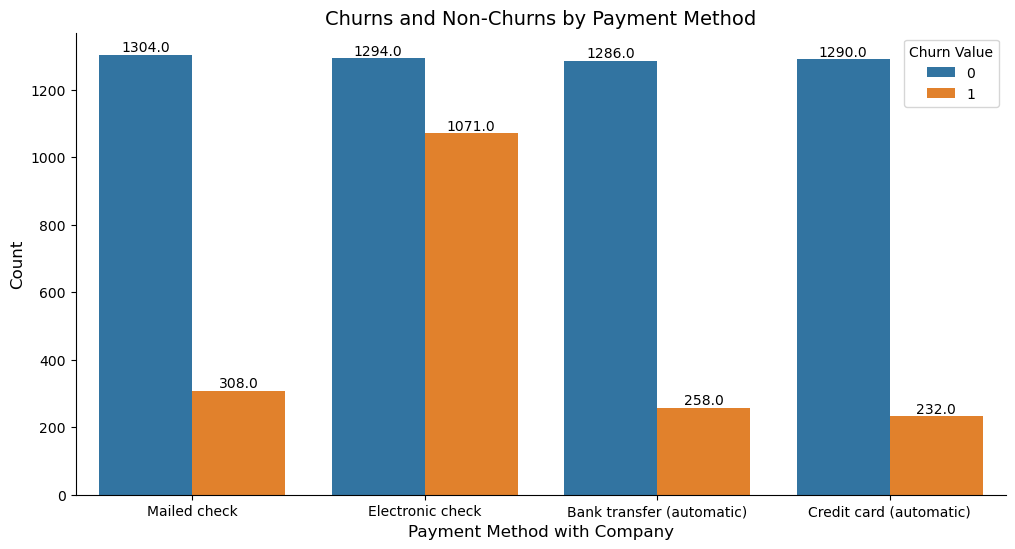

In [36]:
plt.figure(figsize=(12, 6))
payment_meth_count = sns.countplot(data=df, x='Payment Method', hue='Churn Value')

# adding x and y labels
plt.xlabel('Payment Method with Company', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Churns and Non-Churns by Payment Method', fontsize=14)

#sns.despine is use for the clear look
sns.despine()

# showing counts on the top of bar
for count in payment_meth_count.patches:
    height = count.get_height()
    payment_meth_count.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.show()

out of 7043 customers we have 1612 customers who pay their bills by Mailed check and out of this 308 are churners. 

and we have 2365 customers who pay their bills by Electronic check out of this 1071 are churners.

and we have 1544 customers who pay their bills by Bank transfer (automatic) out of this 258 are churners.

and we have 1522 customers who pay their bills by Credit card (automatic) out of this 232 are churners  



overall it shows that churn rate of customers who pay their bills by Mailed check is about 19.1%, the churn rate of a customers who pay their bills by Electronic check is about 45.3%, the churn rate of a customers who pay their bills by Bank transfer (automatic) is about 16.7%, and the churn rate of a customers who pay their bills by Credit card (automatic) is about 15.3%

Hence mostly customer prefer to pay their bills by Electronic check also they experienced higher churn rate on the other hand the customers who pay their bills by Mailed check, Bank transfer and Credit card has lower churn rate.

### 16) Tenure Months with Churn Value 

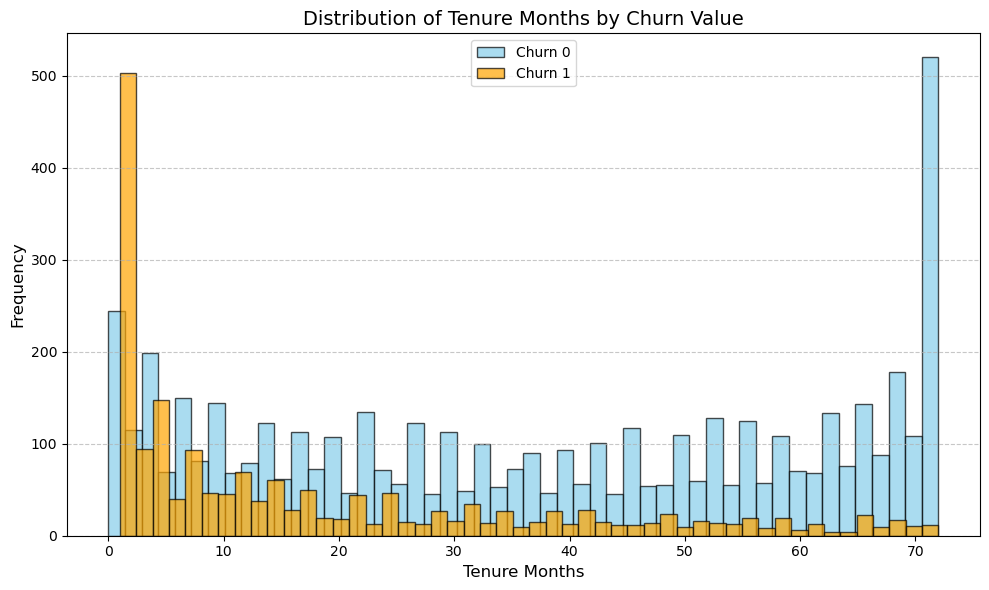

In [37]:
num_bins = 50

plt.figure(figsize=(10, 6))

# plot for the churn value 0 means customer not churn
plt.hist(df['Tenure Months'][df['Churn Value'] == 0], bins=num_bins, edgecolor='k', alpha=0.7, color='skyblue', label='Churn 0')
# Plot for the churn value 1 maens customer churn
plt.hist(df['Tenure Months'][df['Churn Value'] == 1], bins=num_bins, edgecolor='k', alpha=0.7, color='orange', label='Churn 1')

plt.grid(axis='y', linestyle='--', alpha=0.7)

# adding x and y labels
plt.xlabel('Tenure Months', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Tenure Months by Churn Value', fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend()

# using plt.tight_layout to adjust the layout.
plt.tight_layout()
plt.show()


The above histogram shows that the customers with lower tenure months experienced the higher likelihood of churning on the other hand the customers with higher tenure month are less likely to churn that means that if the customer is engagged with the company and getting services for long time seems to be more loyal and will continue using the services but the customer who is just start using the service need more attention because the chances to end up the service is very high.

### 17) Monthly Charges with Churn Value 

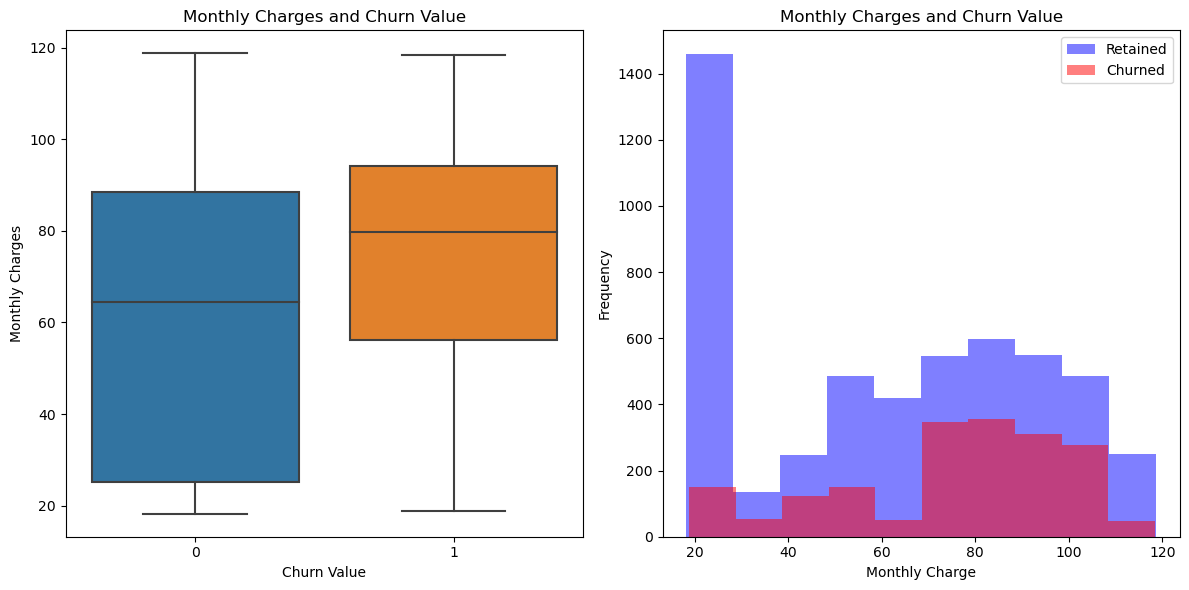

In [38]:
# we use box plot and histogram to see the relationship between monthly charges and churn value so will plot both side by side.
# we will subplot for this.
plt.figure(figsize=(12, 6))

# Box plot to see relationship between monthly charges and churn value
plt.subplot(1, 2, 1) 
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)
plt.xlabel('Churn Value')
plt.ylabel('Monthly Charges')
plt.title('Monthly Charges and Churn Value')

# Histogram to see the count of customer churns and retained
plt.subplot(1, 2, 2)
retained_data = df[df['Churn Value'] == 0]['Monthly Charges']
churned_data = df[df['Churn Value'] == 1]['Monthly Charges']
plt.hist(retained_data, bins=10, alpha=0.5, color='blue', label='Retained')
plt.hist(churned_data, bins=10, alpha=0.5, color='red', label='Churned')
plt.xlabel('Monthly Charge')
plt.ylabel('Frequency')
plt.title('Monthly Charges and Churn Value')
plt.legend()

# using plt.tight_layout to adjust the layout.
plt.tight_layout()
plt.show()


Above box plot and histogram shows that the average customers who churns tend to have a higher monthly charges compare to the customers who are not churn. Which means that the monthly charges can play important role for churning of the customers just like if other company give the same services in a less charges then might the customer end up the relationship with the existing company and switch to other company.

### 18) Churn score with Churn Value 

C:\Users\Rizwan\AppData\Local\Temp\ipykernel_14984\1105126563.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Churn Value'] == 1]['Churn Score'], kde=True, hist=True, label='Churned', color='red')
C:\Users\Rizwan\AppData\Local\Temp\ipykernel_14984\1105126563.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad63727

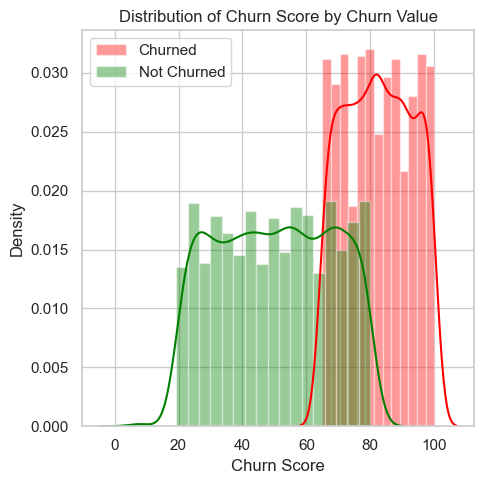

In [39]:
# Creating the distplot
plt.figure(figsize=(5, 5))
sns.set(style="whitegrid")

sns.distplot(df[df['Churn Value'] == 1]['Churn Score'], kde=True, hist=True, label='Churned', color='red')
sns.distplot(df[df['Churn Value'] == 0]['Churn Score'], kde=True, hist=True, label='Not Churned', color='green')

# adding x and y labels
plt.xlabel('Churn Score')
plt.ylabel('Density')
plt.title('Distribution of Churn Score by Churn Value')
plt.legend()

# using plt.tight_layout to adjust the layout.
plt.tight_layout()
plt.show()


Above dist plot shows that the churn score above 60 experience higher customer churns but moreover exceeding 80 score indicates that the vast majority of customers are most likely to be churn

### 19) Top 10 Cities with Churn Value 

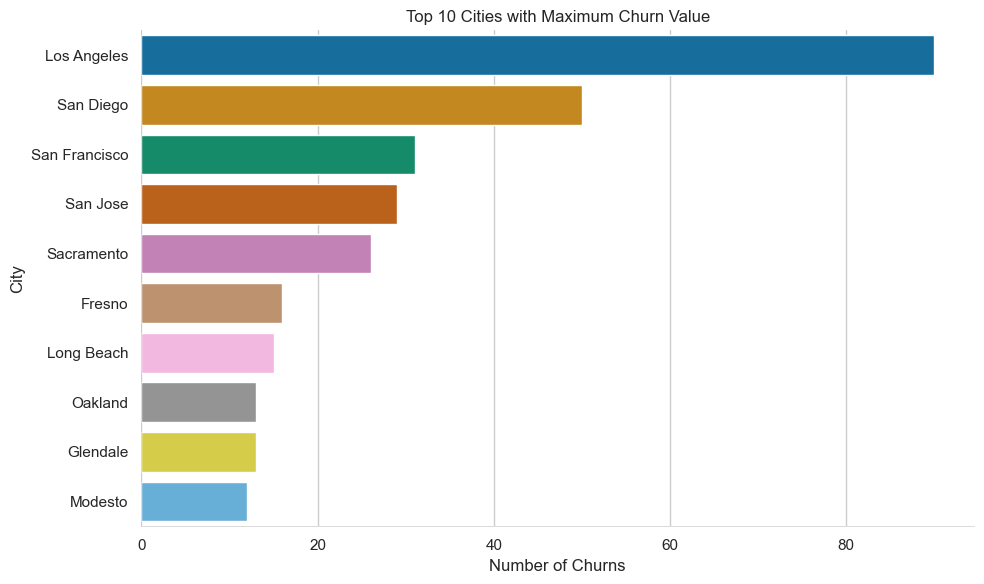

In [40]:
top_citycounts = df[df['Churn Value'] == 1]['City'].value_counts().head(10)

sns.set_palette("colorblind")
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_citycounts.values, y=top_citycounts.index, palette="colorblind")

plt.xlabel('Number of Churns')
plt.ylabel('City')
plt.title('Top 10 Cities with Maximum Churn Value')
sns.despine()
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# using plt.tight_layout to adjust the layout.
plt.tight_layout()

# Showing the plot
plt.show()


The above bar plot shows the top 10 cities which has highest rate of churns in which los angeles experienced most customer churns.

### 20) Analyzing the Churn Reasons

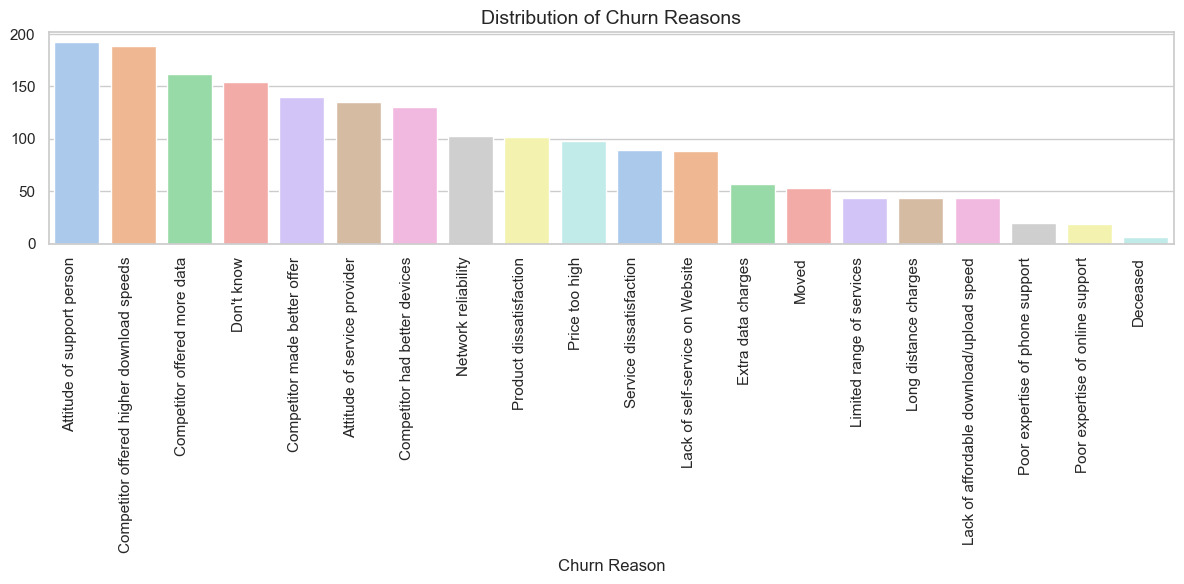

In [41]:
# Create the count plot for "Churn Reason"
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

custom_palette = sns.color_palette("pastel")

# Getting the count of each churn reason in descending order
reason_counts = df['Churn Reason'].value_counts().sort_values(ascending=False)

sns.countplot(x='Churn Reason', data=df, palette=custom_palette, order=reason_counts.index)
plt.xticks(rotation=90, ha='right')

# Removing y-axis label
plt.ylabel('')

# adding x label and title
plt.xlabel('Churn Reason', fontsize=12)
plt.title('Distribution of Churn Reasons', fontsize=14)

# using plt.tight_layout to adjust the layout.
plt.tight_layout()
plt.show()


In above count plot it can be seen that the two most highest churns reasons are 'Attitude of support person' and second is 'competitor offered higher download speed' if we see rest of the reasons like 'competitor offered more data' it seems like the services which internet service providers are giving effect more customers to be churn moreover the most important thing for any organization is customer support with above graph it is also can be seen that most customers are churn because of customer support in terms of 'attitude of support person'.

### 21) Analyzing Churn Rates of Senior Citizen Dependents Based on Gender 

C:\Users\Rizwan\AppData\Local\Temp\ipykernel_14984\909690091.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Dependents', y='Churn Value', hue='Senior Citizen', data=male_data, ax=ax1, ci=None)
C:\Users\Rizwan\AppData\Local\Temp\ipykernel_14984\909690091.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Dependents', y='Churn Value', hue='Senior Citizen', data=female_data, ax=ax2, ci=None)


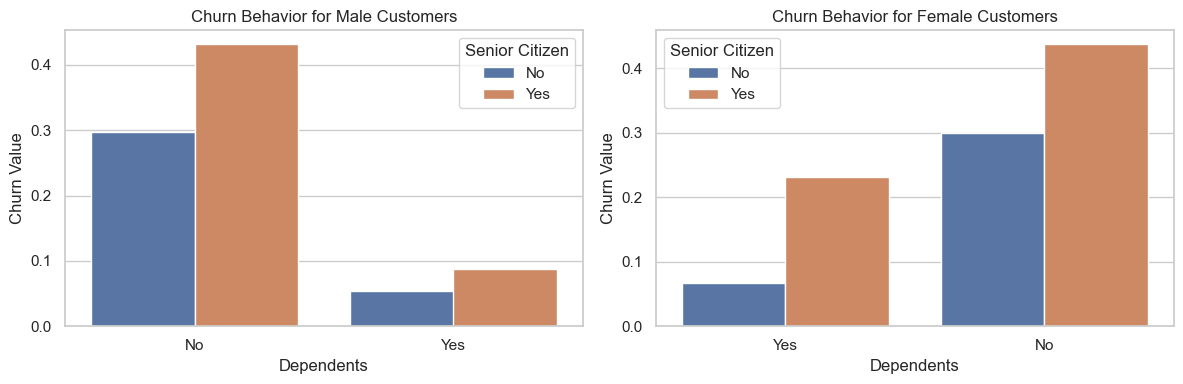

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Create subplots for Male customers
ax1 = axes[0]
male_data = df[df['Gender'] == 'Male']
sns.barplot(x='Dependents', y='Churn Value', hue='Senior Citizen', data=male_data, ax=ax1, ci=None)
ax1.set_title('Churn Behavior for Male Customers')
ax1.set_xlabel('Dependents')
ax1.set_ylabel('Churn Value')

# Create subplots for Female customers
ax2 = axes[1]
female_data = df[df['Gender'] == 'Female']
sns.barplot(x='Dependents', y='Churn Value', hue='Senior Citizen', data=female_data, ax=ax2, ci=None)
ax2.set_title('Churn Behavior for Female Customers')
ax2.set_xlabel('Dependents')
ax2.set_ylabel('Churn Value')

# using plt.tight_layout to adjust the layout.
plt.tight_layout()

plt.show()


In above bar plot it can be seen that the male senior citizens who are having dependents are very less though they expericed less churns on the other hand male senior citizens who are not having dependents are very high and also expericed more churns

For the females it can be seen that the female senior citizens who are having dependents are less though they expericed high churns on the other hand female senior citizens who are not having dependents are very high and also expericed more churns

### 22) Plotting Bar graph to show Churn Rates of Gender, Senior Citizen, Partner and Dependents

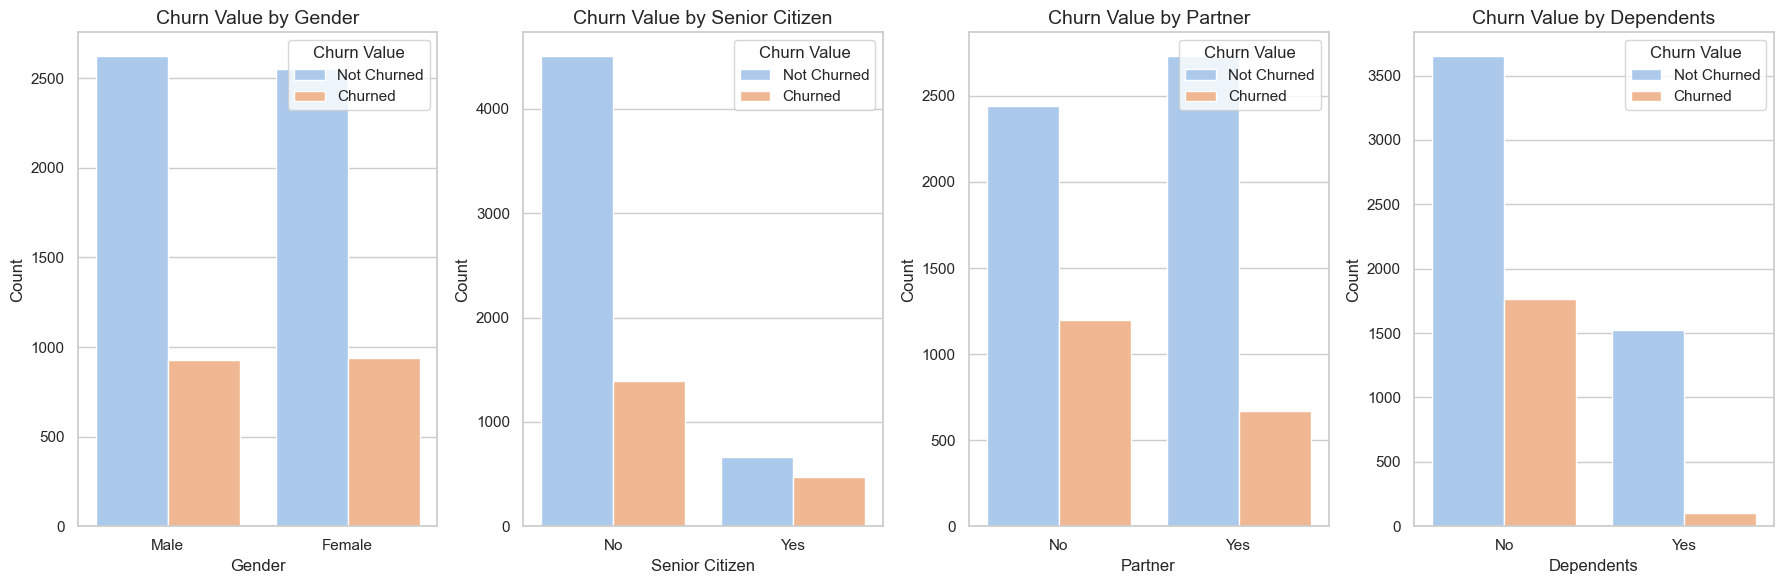

In [43]:
# creating group plot
columns_to_plot = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']

plt.figure(figsize=(18, 6))
sns.set(style="whitegrid")

for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1)
    sns.countplot(x=column, hue='Churn Value', data=df, palette='pastel')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Churn Value', labels=['Not Churned', 'Churned'])
    plt.title(f'Churn Value by {column}', fontsize=14)

# using plt.tight_layout to adjust the layout.
plt.tight_layout()

# Show the plot
plt.show()


### 23) Analyzing Churn Rates of Senior Citizen, Partner and Dependents Based on Gender 

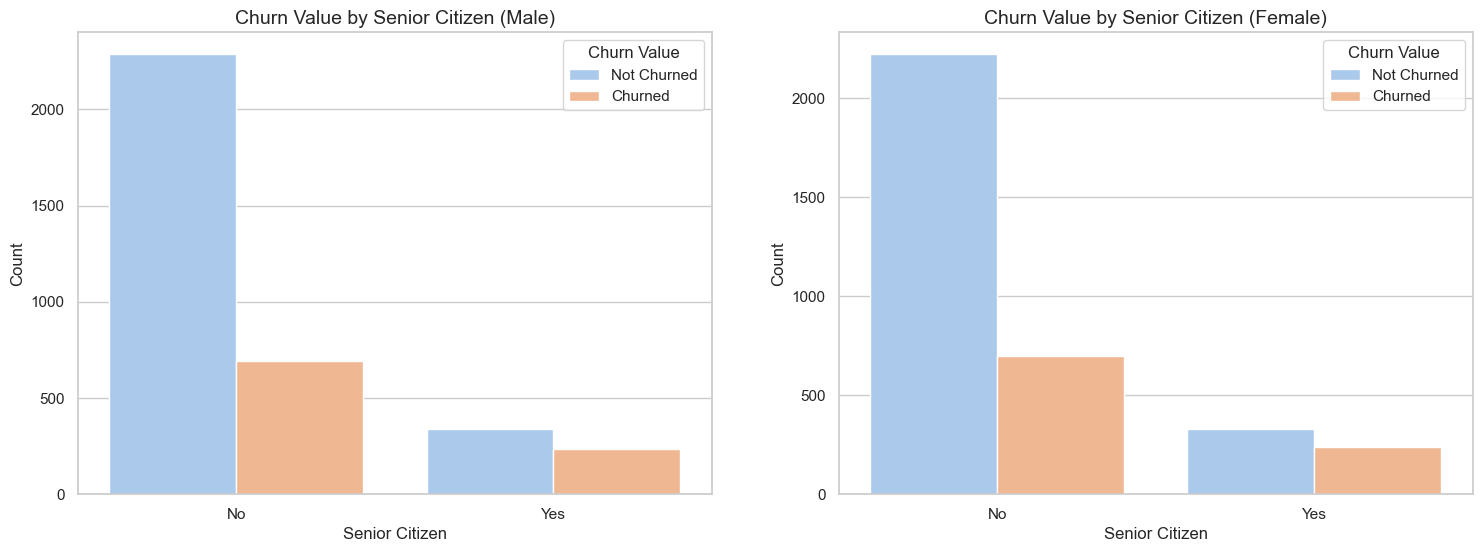

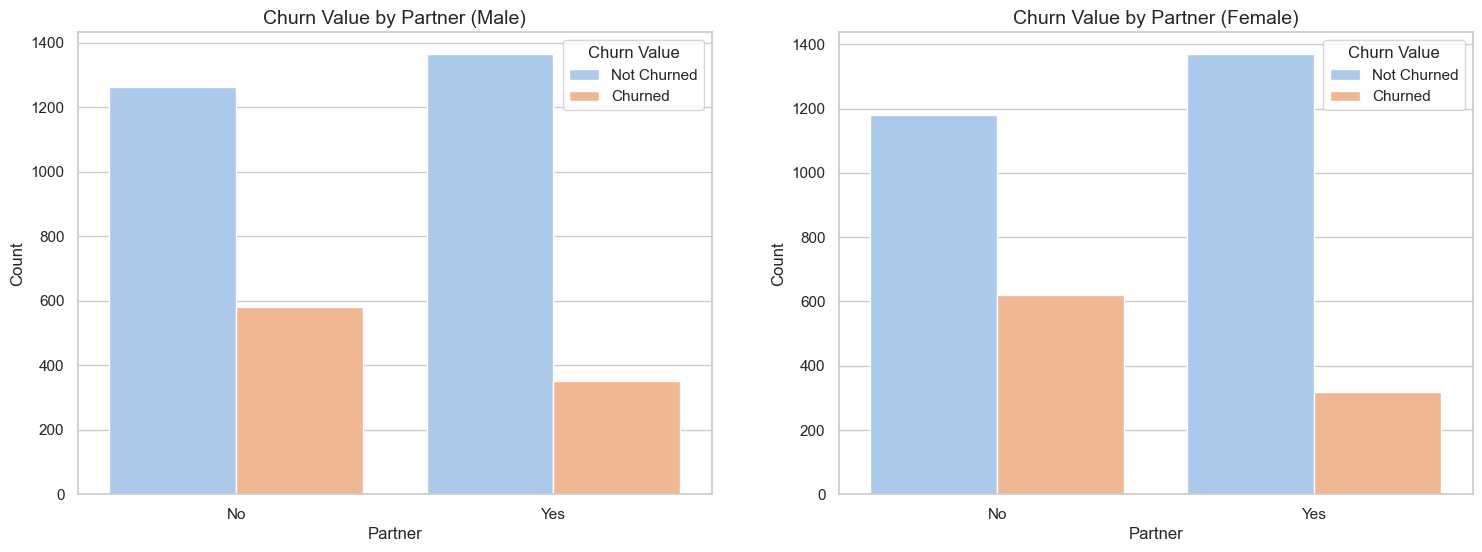

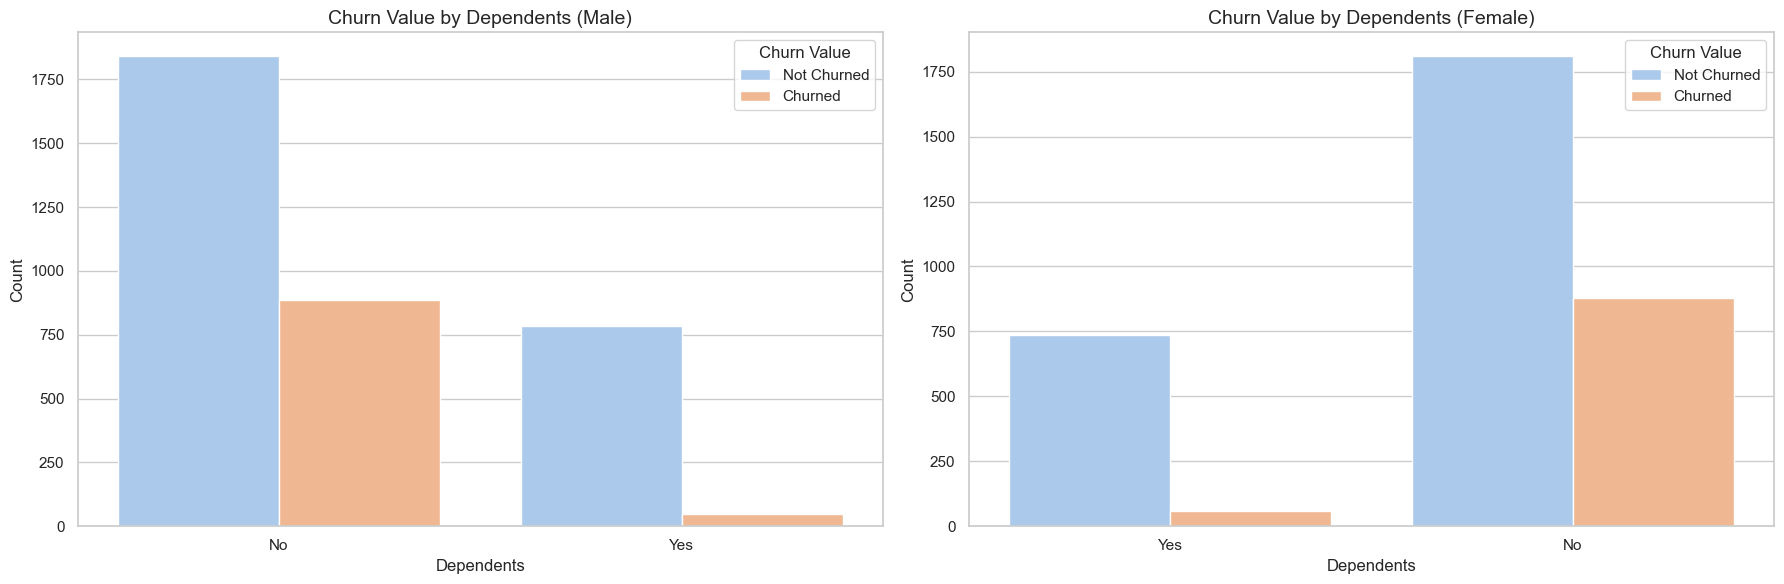

In [44]:
# creating group plot
columns_to_plot = ['Senior Citizen', 'Partner', 'Dependents']

sns.set(style="whitegrid")

for i, column in enumerate(columns_to_plot):
    plt.figure(figsize=(18, 6))
    
    for gender in df['Gender'].unique():
        plt.subplot(1, 2, 1 if gender == 'Male' else 2)
        sns.countplot(x=column, hue='Churn Value', data=df[df['Gender'] == gender], palette='pastel')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.legend(title='Churn Value', labels=['Not Churned', 'Churned'])
        plt.title(f'Churn Value by {column} ({gender})', fontsize=14)
        
# using plt.tight_layout to adjust the layout.
plt.tight_layout()
    
plt.show()

It can be seen that there is a minimal difference between genders in terms of different factors like having dependents, partners being senior citizens

#### 24) Plotting Bar graph to show Churn Rates of Phone Service, Multiple Lines and Internet Service

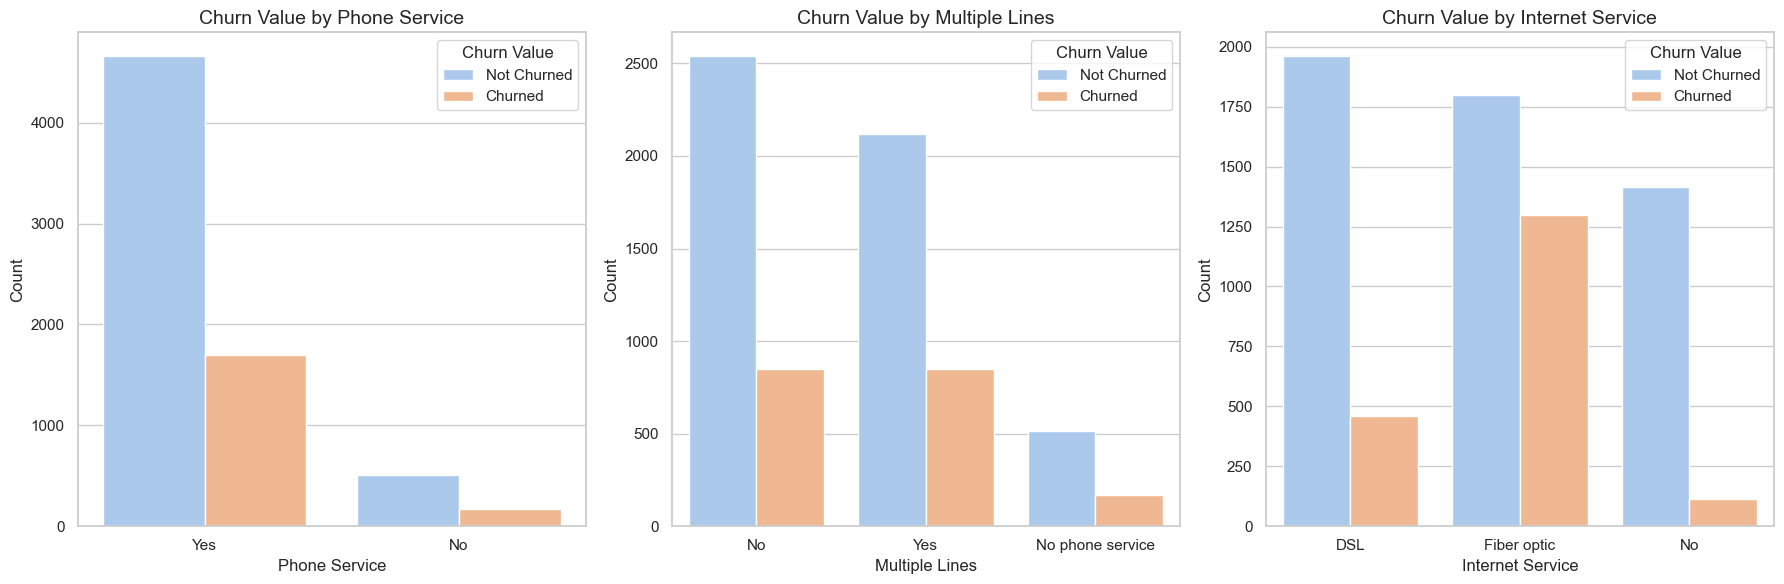

In [45]:
# creating group plot
columns_to_plot = ['Phone Service', 'Multiple Lines', 'Internet Service']

plt.figure(figsize=(18, 6))
sns.set(style="whitegrid")

for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1)
    sns.countplot(x=column, hue='Churn Value', data=df, palette='pastel')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Churn Value', labels=['Not Churned', 'Churned'])
    plt.title(f'Churn Value by {column}', fontsize=14)

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


#### 25) Plotting Bar graph to show Churn Rates of Internet Service, Online Security, Online Backup, Device Protection and Tech Support

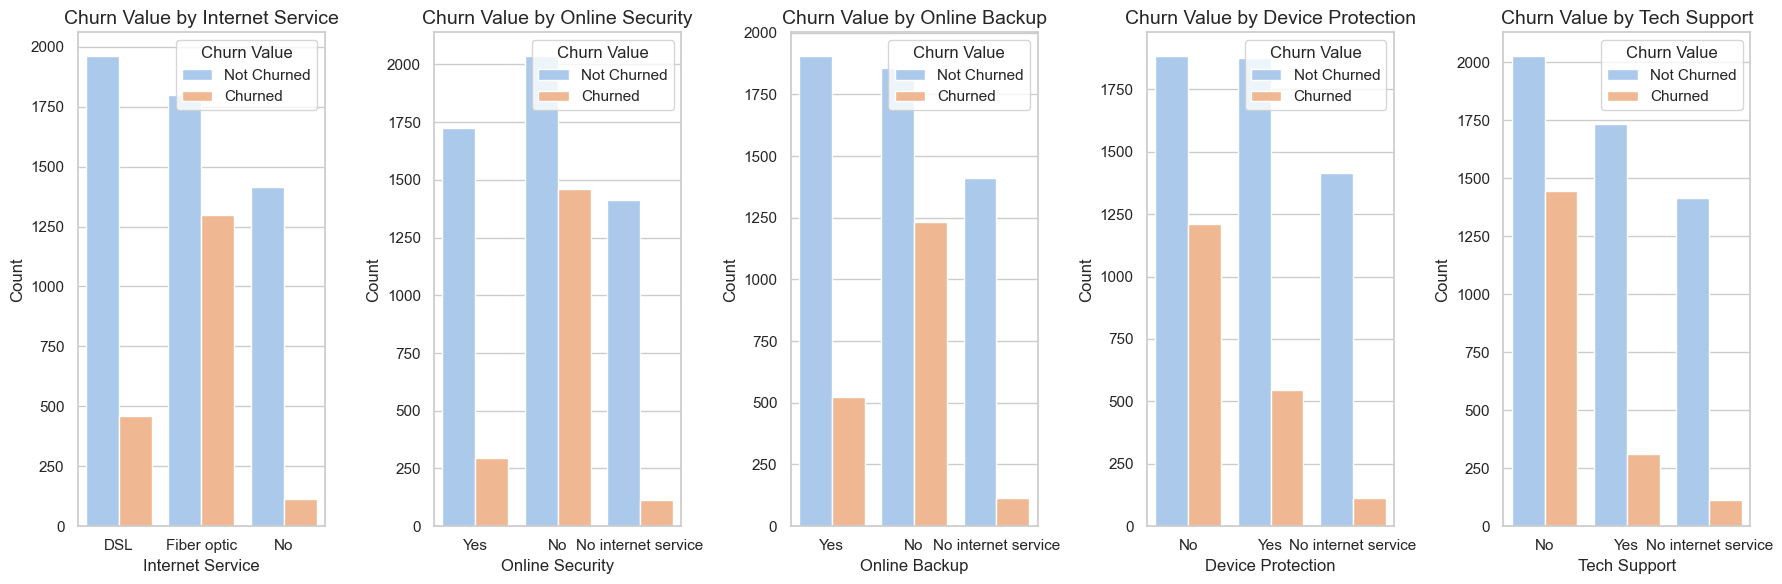

In [46]:
# creating group plot
columns_to_plot = ['Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support']

plt.figure(figsize=(18, 6))
sns.set(style="whitegrid")

for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1)
    sns.countplot(x=column, hue='Churn Value', data=df, palette='pastel')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Churn Value', labels=['Not Churned', 'Churned'])
    plt.title(f'Churn Value by {column}', fontsize=14)

# using plt.tight_layout to adjust the layout.
plt.tight_layout()

plt.show()


#### 26) Analyzing Churn Rates of Internet Service, Online Security, Online Backup, Device Protection Based on Gender 

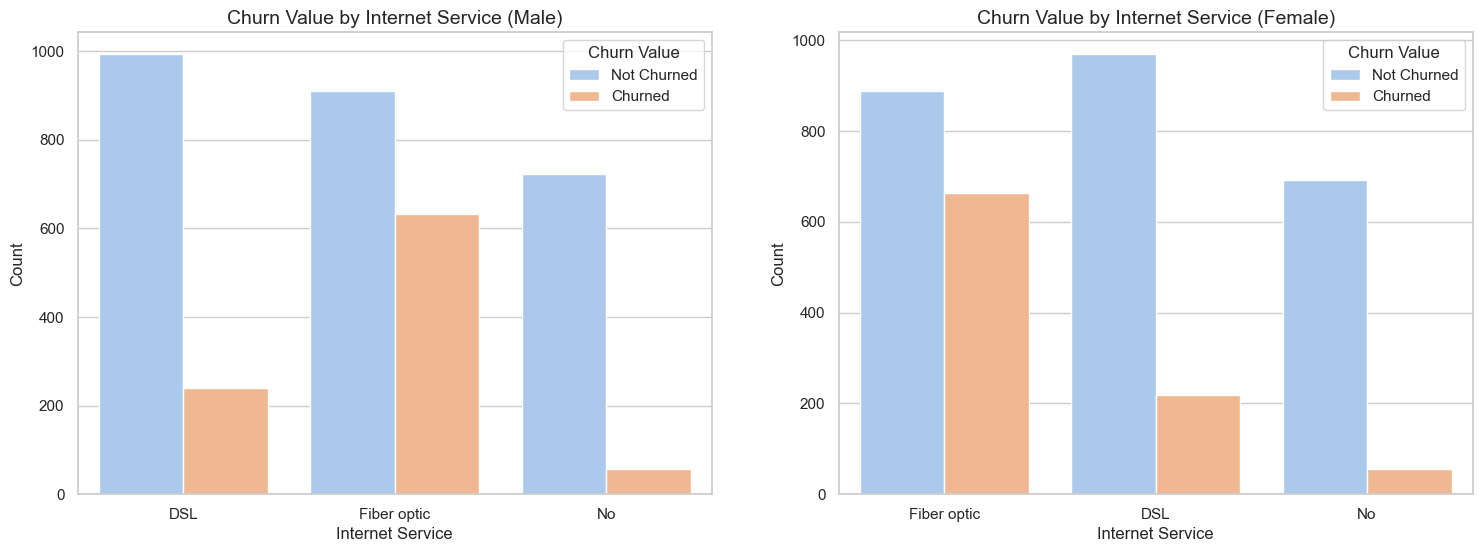

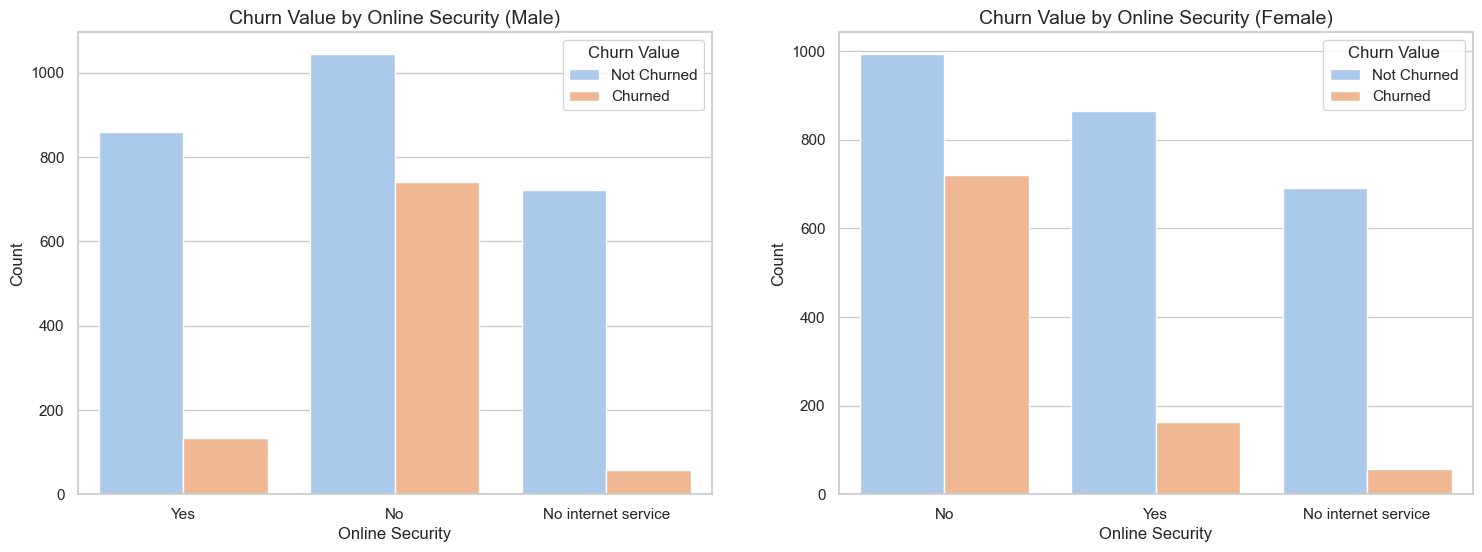

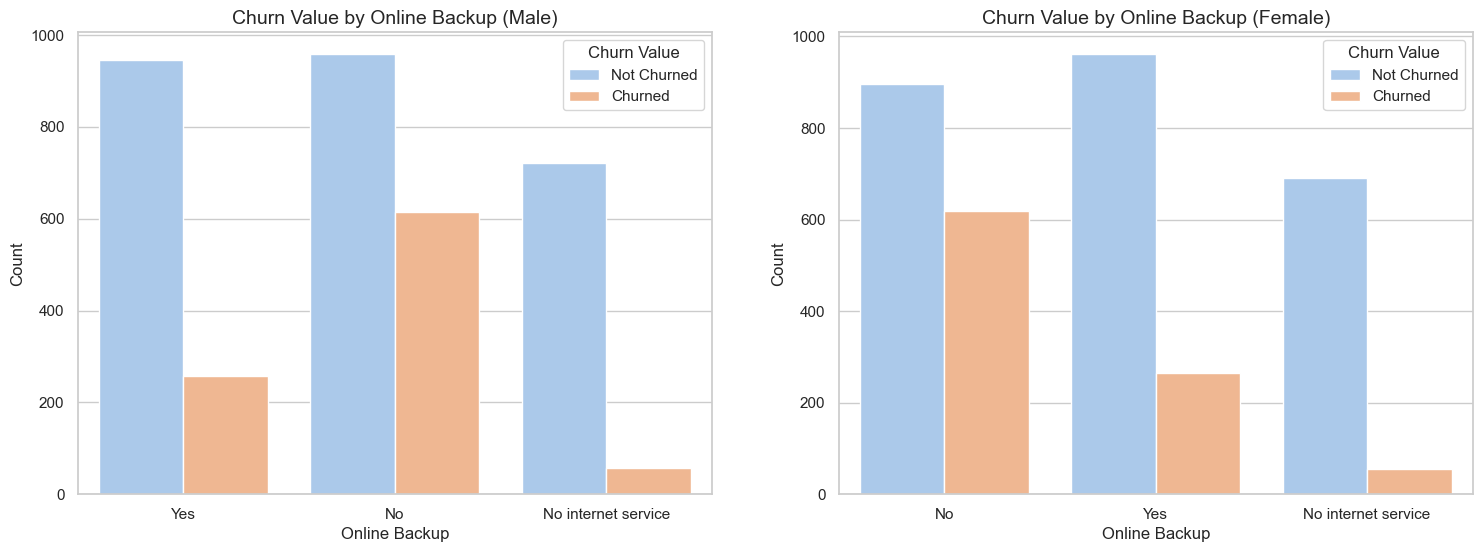

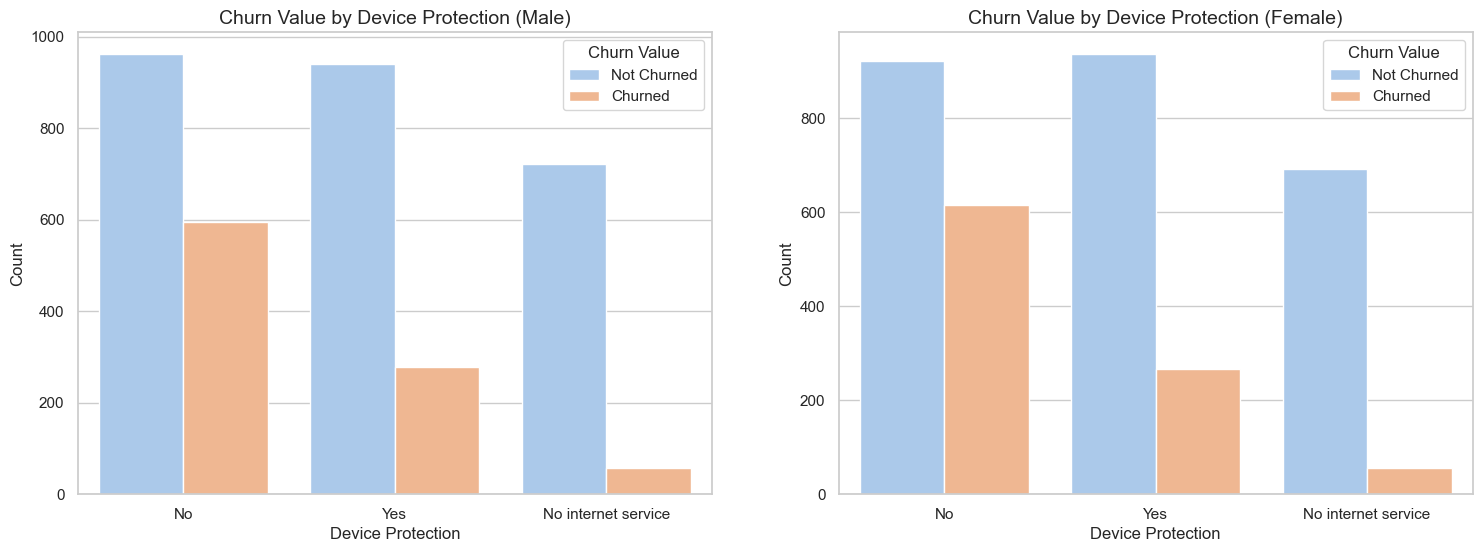

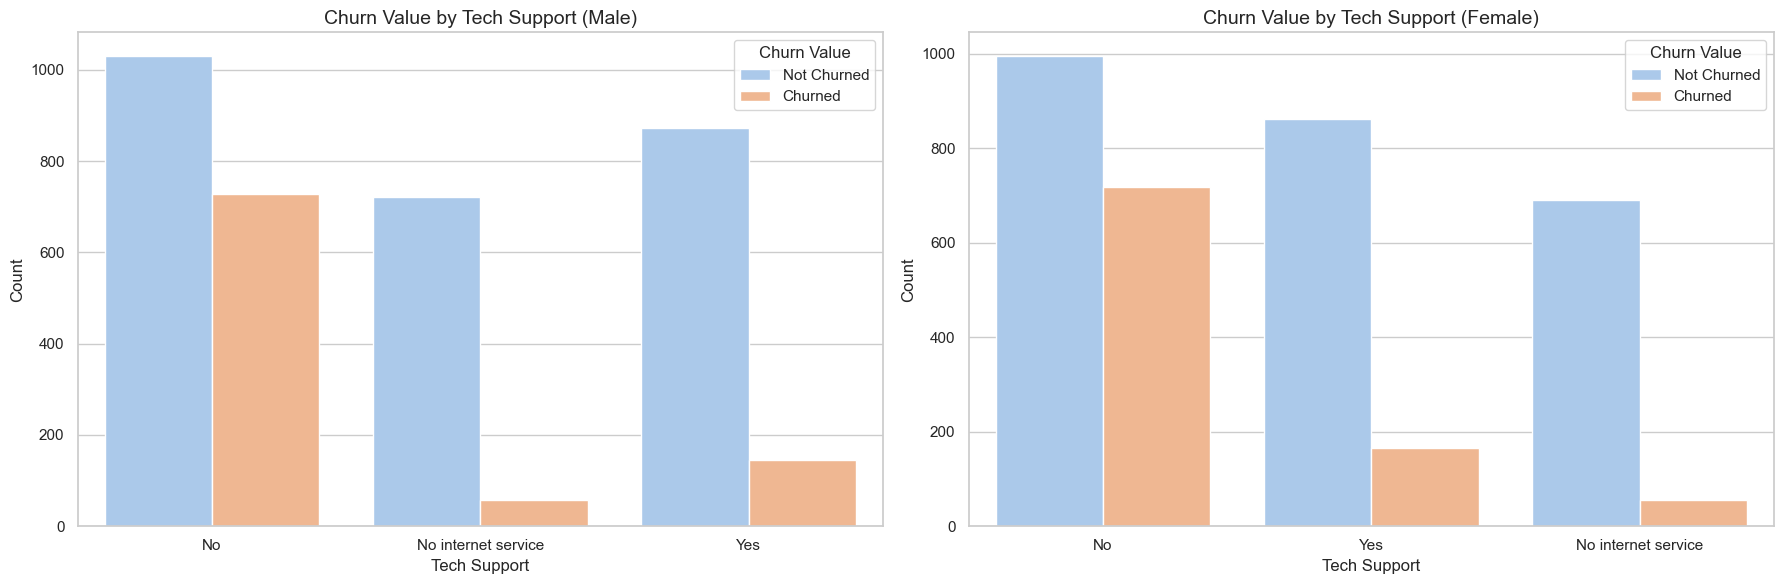

In [47]:
# creating group plot
columns_to_plot = ['Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support']

sns.set(style="whitegrid")

for i, column in enumerate(columns_to_plot):
    plt.figure(figsize=(18, 6))
    
    for gender in df['Gender'].unique():
        plt.subplot(1, 2, 1 if gender == 'Male' else 2)
        sns.countplot(x=column, hue='Churn Value', data=df[df['Gender'] == gender], palette='pastel')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.legend(title='Churn Value', labels=['Not Churned', 'Churned'])
        plt.title(f'Churn Value by {column} ({gender})', fontsize=14)
        
# using plt.tight_layout to adjust the layout.
plt.tight_layout()
    
plt.show()


It can be seen that there is a minimal difference between genders in terms of different factors like Internet service, Online backup, Online security, Device protection and tech support.

#### 27) Analyzing Churn Rates of Internet Service, Online Security, Online Backup, Device Protection Based on Dependents

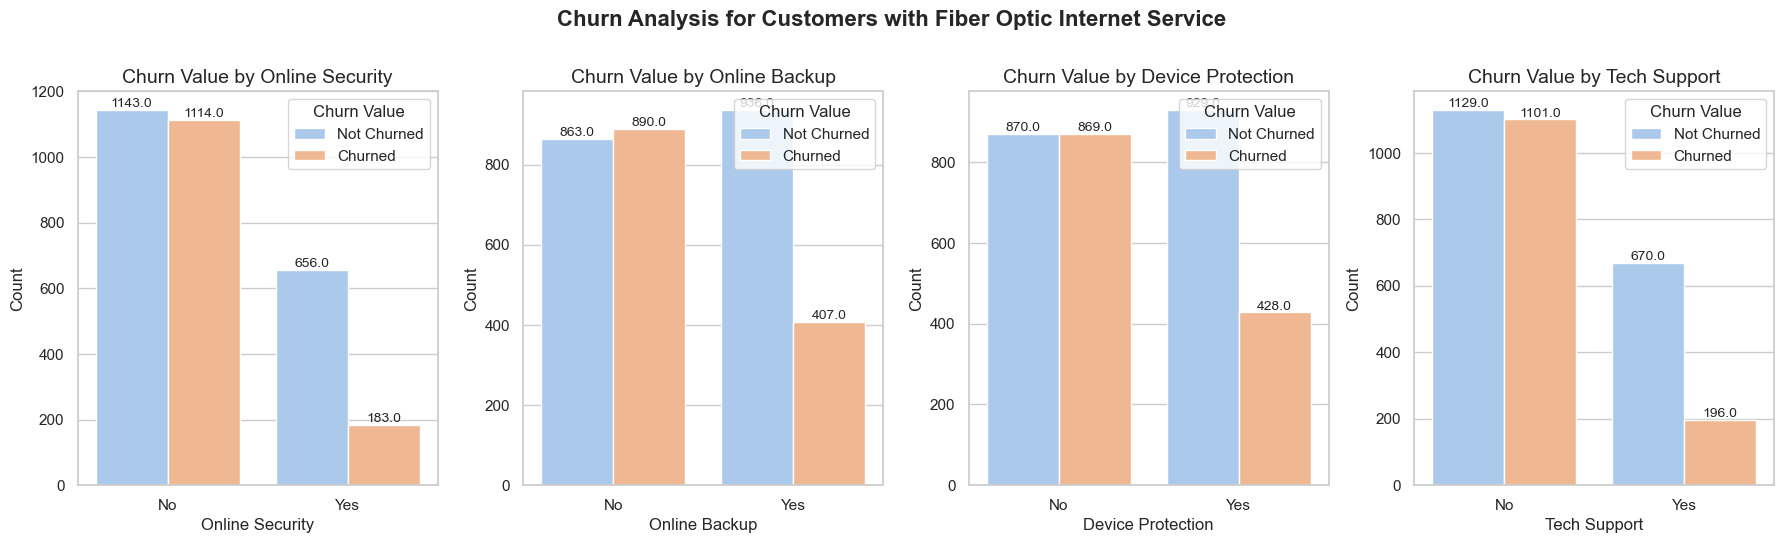

In [48]:
# creating group plot
columns_to_plot = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support']

plt.figure(figsize=(18, 5))
sns.set(style="whitegrid")

# Filter data for 'Internet Service' value equal to 'Fiber optic'
df_fiber_optic = df[df['Internet Service'] == 'Fiber optic']

plt.figtext(0.5, 1.05, 'Churn Analysis for Customers with Fiber Optic Internet Service', fontsize=16, fontweight='bold', ha='center')
plt.figtext(0.5, 25, '', ha='center')

for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1)
    ax = sns.countplot(x=column, hue='Churn Value', data=df_fiber_optic, palette='pastel')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Churn Value', labels=['Not Churned', 'Churned'])
    plt.title(f'Churn Value by {column}', fontsize=14)
    
    # showing counts on the top of bar
    for count in ax.patches:
        height = count.get_height()
        ax.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

# using plt.tight_layout to adjust the layout.
plt.tight_layout()

plt.show()

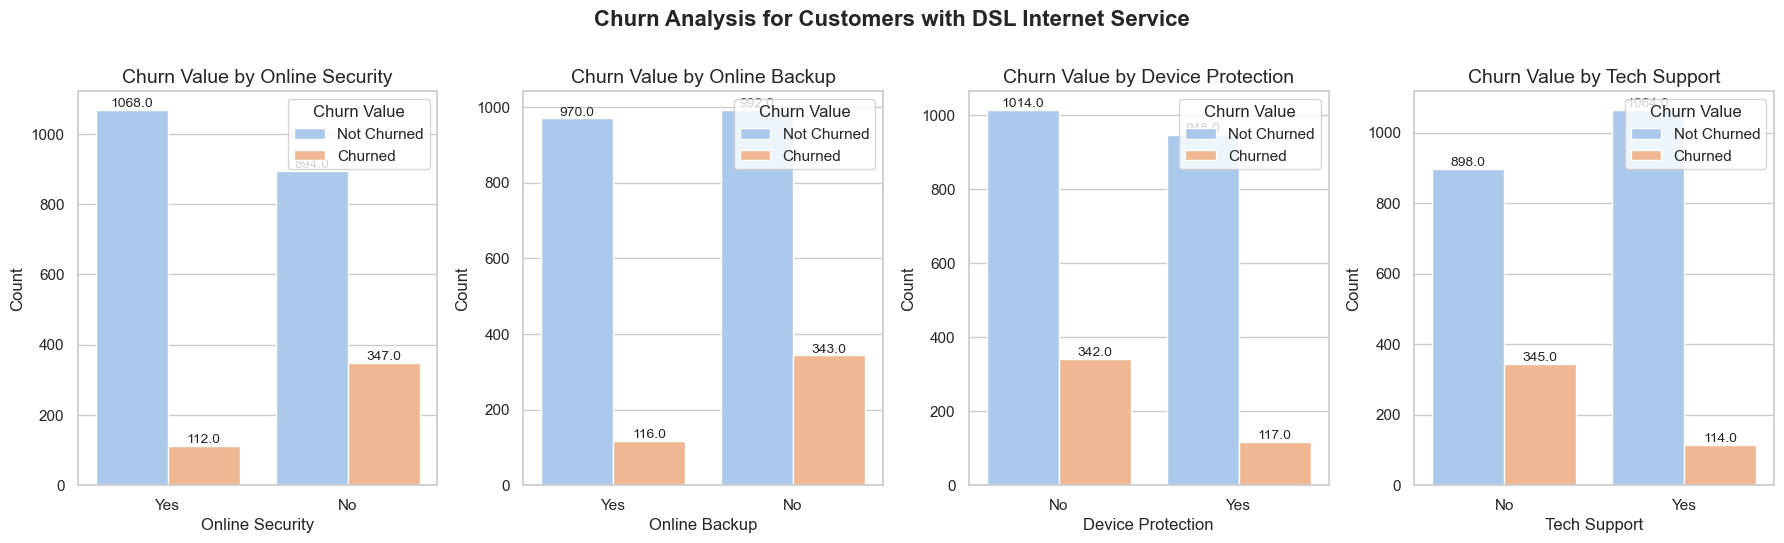

In [49]:
# creating group plot
columns_to_plot = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support']

plt.figure(figsize=(18, 5))
sns.set(style="whitegrid")

# Filter data for 'Internet Service' value equal to 'Fiber optic'
df_DSL = df[df['Internet Service'] == 'DSL']

plt.figtext(0.5, 1.05, 'Churn Analysis for Customers with DSL Internet Service', fontsize=16, fontweight='bold', ha='center')
plt.figtext(0.5, 25, '', ha='center')

for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1)
    ax = sns.countplot(x=column, hue='Churn Value', data=df_DSL, palette='pastel')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Churn Value', labels=['Not Churned', 'Churned'])
    plt.title(f'Churn Value by {column}', fontsize=14)
    
    # showing counts on the top of bar
    for count in ax.patches:
        height = count.get_height()
        ax.annotate(f'{height}', (count.get_x() + count.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

# using plt.tight_layout to adjust the layout.
plt.tight_layout()

plt.show()

# Data Preprocessing 

In [50]:
# making a copy of dataframe
df2 = df.copy()

In [51]:
# dropping some columns which are not usefull
drop_col = ['CustomerID','City','Zip Code','Latitude','Longitude','Count','Country','State','Lat Long','CLTV','Churn Score','Churn Label','Churn Reason']

df2 = df2.drop(columns=drop_col,axis=1)

In [52]:
df2.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

### One-Hot Encoding  

In [53]:
# using one-hot encoding to convert the categorical data into numerical data

cat_cols = ['Gender','Senior Citizen','Partner','Dependents','Phone Service','Multiple Lines','Internet Service',
               'Online Security','Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies',
               'Contract','Paperless Billing','Payment Method']


# using pd.get_dummies() for one-hot encoding
encoded_cat_df = pd.get_dummies(df2[cat_cols])

# dropping the old categorical columns
df2 = df2.drop(columns=cat_cols)

encoded_df2 = pd.concat([encoded_cat_df, df2], axis=1)

encoded_df2.head()

,Gender_Female,Gender_Male,Senior Citizen_No,Senior Citizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,Phone Service_No,Phone Service_Yes,...,Paperless Billing_No,Paperless Billing_Yes,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Months,Monthly Charges,Total Charges,Churn Value
0,0,1,1,0,1,0,1,0,0,1,...,0,1,0,0,0,1,2,53.85,108.15,1
1,1,0,1,0,1,0,0,1,0,1,...,0,1,0,0,1,0,2,70.70,151.65,1
2,1,0,1,0,1,0,0,1,0,1,...,0,1,0,0,1,0,8,99.65,820.50,1
3,1,0,1,0,0,1,0,1,0,1,...,0,1,0,0,1,0,28,104.80,3046.05,1
4,0,1,1,0,1,0,0,1,0,1,...,0,1,1,0,0,0,49,103.70,5036.30,1


In [54]:
encoded_df2.shape

(7043, 47)

After one-hot encoding now we have 51 columns now its time to do a feature selection

# draw a heatmap

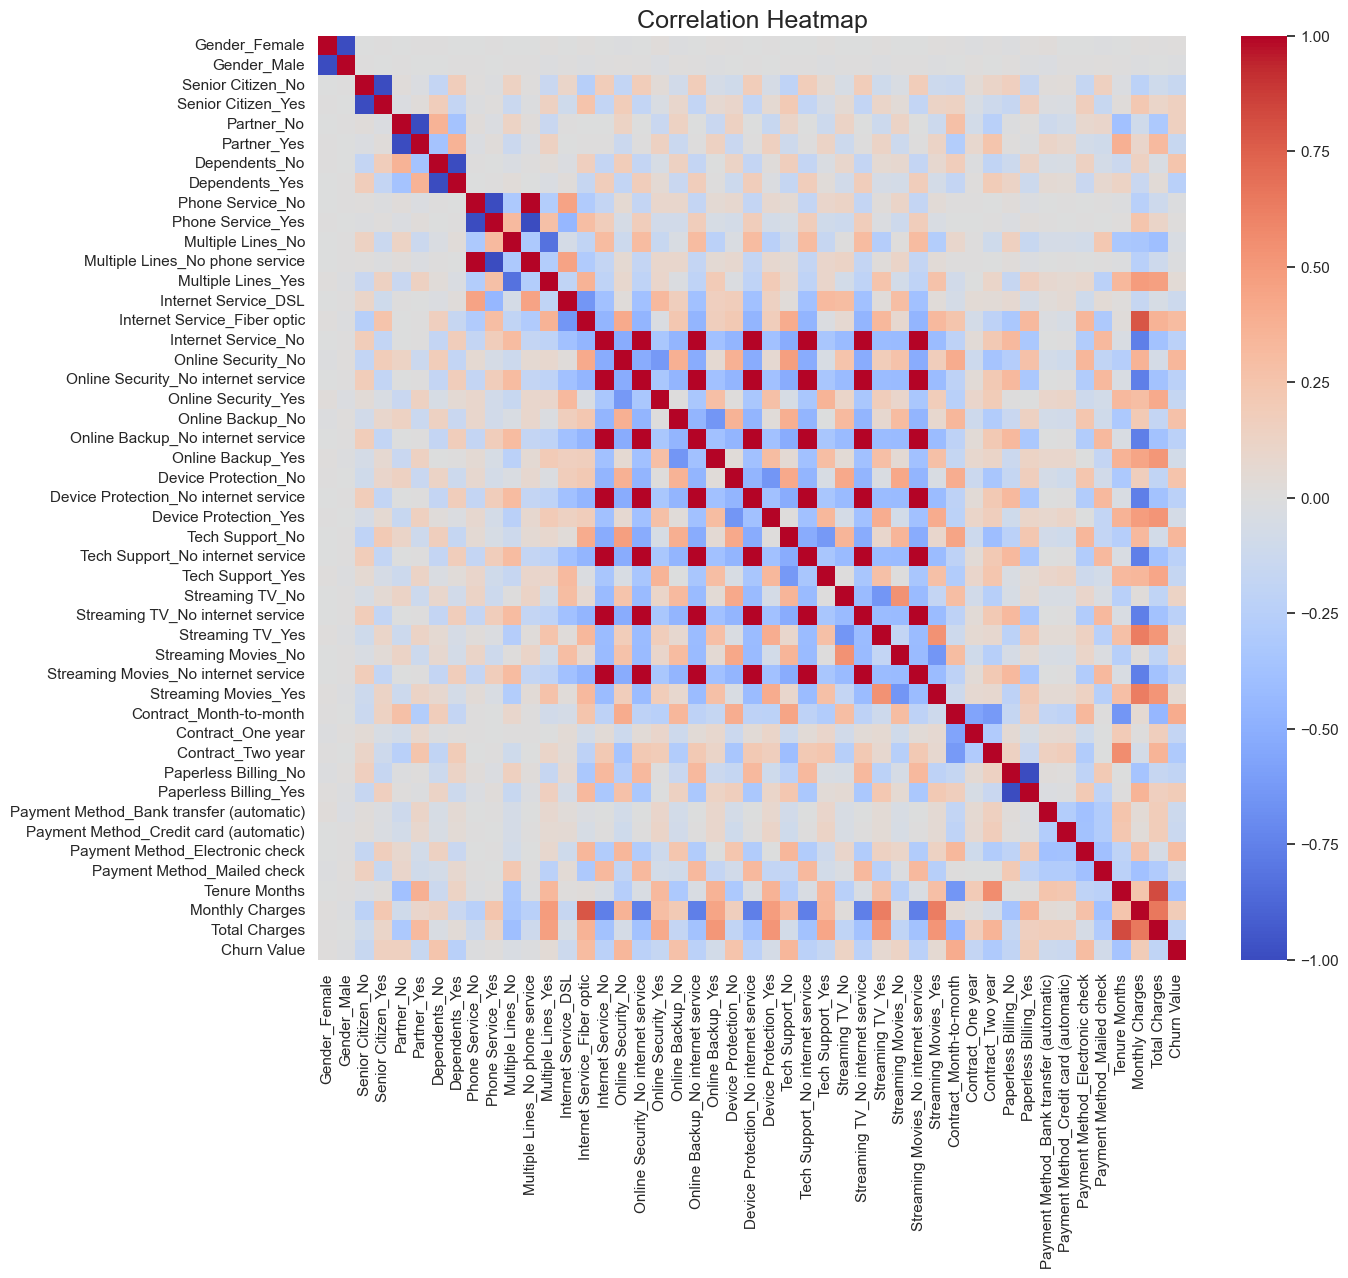

In [55]:
#making correlation heatmap
correlation_matrix = encoded_df2.corr()

plt.figure(figsize=(14, 12)) 
heatmap = sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
heatmap.set_title("Correlation Heatmap", fontsize=18)  

plt.show()

### Feature Selection Using ElasticNet Regression 

Selected features using Elastic Net Regression:
Index(['Dependents_No', 'Dependents_Yes', 'Internet Service_Fiber optic',
       'Online Security_No', 'Tech Support_No', 'Contract_Month-to-month',
       'Payment Method_Electronic check', 'Tenure Months'],
      dtype='object')


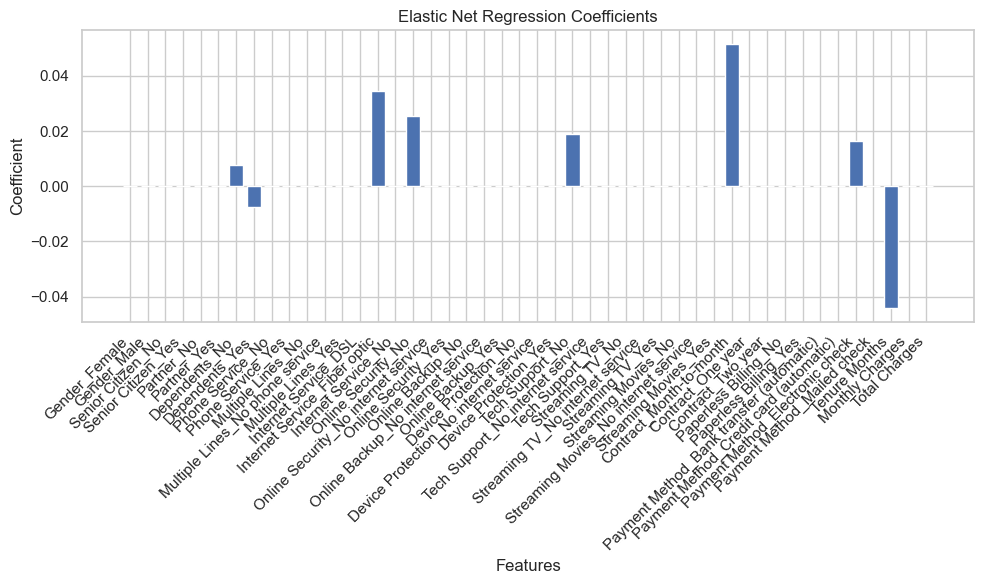

In [56]:
# Separate features (X) and target (y)
X = encoded_df2.drop('Churn Value', axis=1)
y = encoded_df2['Churn Value']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Create the Elastic Net Regression model
alpha = 0.1  
l1_ratio = 0.6  
elastic_net_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

elastic_net_model.fit(X_train_std, y_train)
selected_features_indices = np.where(elastic_net_model.coef_ != 0)[0]
selected_features = X.columns[selected_features_indices]

# Printing the selected features
print("Selected features using Elastic Net Regression:")
print(selected_features)


plt.figure(figsize=(10, 6))
plt.bar(X.columns, elastic_net_model.coef_)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Coefficient')
plt.title('Elastic Net Regression Coefficients')
plt.tight_layout()
plt.show()


After performing feature selection using ElasticNet Regression, we have a total of 8 columns: ['Dependents_No', 'Dependents_Yes', 'Internet Service_Fiber optic', 'Online Security_No', 'Tech Support_No', 'Contract_Month-to-month', 'Payment Method_Electronic check', 'Tenure Months']. To select the main features, I will consider columns that represent the main category and also include monthly charges column in it, as it is seems to be a important feature. For example, I have chosen the feature 'Online Security_No,' which has a corresponding 'Yes' and 'No Internet Service' value. Hence, I will include all three columns related to 'Online Security' in our model. Similarly will do it for all features. 

I will proceed to train our model using all the columns and by using only the selected columns. By doing this, I will compare the accuracy of both models to check the impact of feature selection on the model's performance.

# Handling imbalance Dataset with Over Sampling 

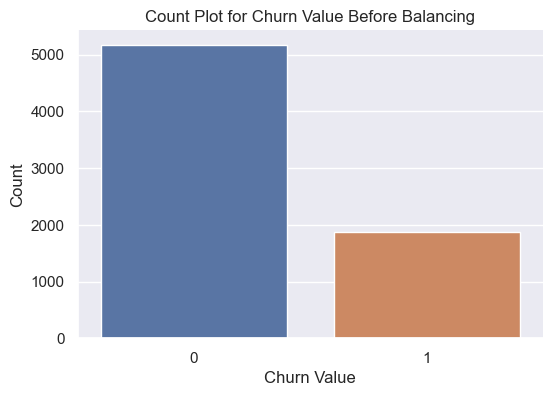

0    5174
1    1869
Name: Churn Value, dtype: int64

In [57]:
#lets plot the count plot to check the imbalance data
sns.set(style='darkgrid')
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn Value', data=df)
plt.title('Count Plot for Churn Value Before Balancing')
plt.xlabel('Churn Value')
plt.ylabel('Count')
sns.despine()
plt.show()


df['Churn Value'].value_counts()

It can be seen that our data is imbalance as we have 5174 [0] values and 1869 [1] values we need to make it as a balance dataset for that will use random oversampling

In [58]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [59]:
selected_features = ['Dependents_No', 'Dependents_Yes', 'Internet Service_Fiber optic',
                       'Online Security_No', 'Tech Support_No', 'Contract_Month-to-month',
                       'Payment Method_Electronic check', 'Tenure Months','Monthly Charges']

In [60]:
X = encoded_df2.drop('Churn Value', axis='columns')
y = encoded_df2['Churn Value']

Xs = encoded_df2[selected_features]
ys = encoded_df2['Churn Value']

In [61]:
y.value_counts()

0    5174
1    1869
Name: Churn Value, dtype: int64

In [62]:
ys.value_counts()

0    5174
1    1869
Name: Churn Value, dtype: int64

In [63]:
# I use smote to balance the dataset
smote = SMOTE(sampling_strategy='minority')
X_balance_all, y_balance_all = smote.fit_resample(X,y)
X_balance_selected, y_balance_selected = smote.fit_resample(Xs,ys)


y_balance_all.value_counts()

1    5174
0    5174
Name: Churn Value, dtype: int64

In [64]:
# checking the count of churns
y_balance_selected.value_counts()

1    5174
0    5174
Name: Churn Value, dtype: int64

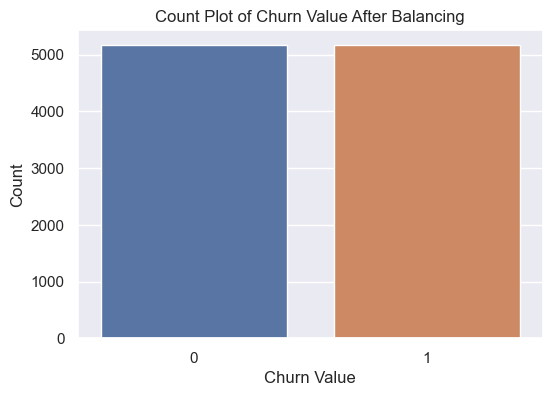

In [65]:
# plotting the count plot to see the churn values after balancing the dataset
sns.set(style='darkgrid')
plt.figure(figsize=(6, 4))
sns.countplot(x=y_balance_all)
plt.xlabel('Churn Value')
plt.ylabel('Count')
plt.title('Count Plot of Churn Value After Balancing')
plt.show()

In [66]:
X_balance_all.value_counts().sum()
X_balance_selected.value_counts().sum()

10348

So now we have total 10348 records after balancing the dataset 

# Applying Machine Learning Algorithms 

In [67]:
#Split the data into training and testing
X_train_all_fea, X_test_all_fea, y_train_all_fea, y_test_all_fea = train_test_split(X_balance_all, y_balance_all, test_size=0.2, random_state=42)

# Standardizing the features
scaler_all_fea = StandardScaler()
X_train_all_fea_std = scaler_all_fea.fit_transform(X_train_all_fea)
X_test_all_fea_std = scaler_all_fea.transform(X_test_all_fea)


# Split the data into training and testing
X_train_sel_fea, X_test_sel_fea, y_train_sel_fea, y_test_sel_fea = train_test_split(X_balance_selected, y_balance_selected, test_size=0.2, random_state=42)

# Standardizing the features
scaler_sel_fea = StandardScaler()
X_train_sel_fea_std = scaler_sel_fea.fit_transform(X_train_sel_fea)
X_test_sel_fea_std = scaler_sel_fea.transform(X_test_sel_fea)

## logistic Regression 

E:\anaconda\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Model Performance: 


Accuracy with all features: 0.86
Precision with all features: 0.88
Recall with all features: 0.83
F1-Score with all features: 0.86


Accuracy with selected features: 0.77
Precision with selected features: 0.77
Recall with selected features: 0.78
F1-Score with selected features: 0.77


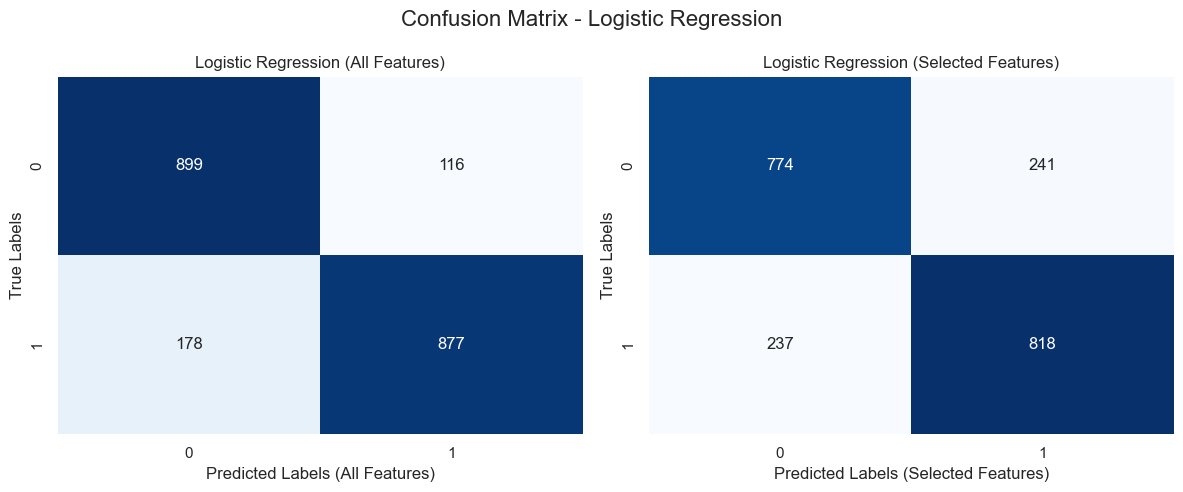

E:\anaconda\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
E:\anaconda\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check

Cross-Validation Scores (All Features): [0.82125604 0.84057971 0.84299517 0.85990338 0.85628019 0.83333333
 0.84178744 0.81763285 0.85610641 0.85368803]
Average Cross-Validation Score (All Features): 0.8423562553668752

Cross-Validation Scores (Selected Features): [0.75       0.75241546 0.75845411 0.78019324 0.77415459 0.75483092
 0.76811594 0.76086957 0.77146312 0.75453446]
Average Cross-Validation Score (Selected Features): 0.7625031398045437


E:\anaconda\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
# Creating Logistic Regression model with all features
log_model_all = LogisticRegression(random_state=42)
log_model_all.fit(X_train_all_fea_std, y_train_all_fea)

# Making prediction
y_pred_all = log_model_all.predict(X_test_all_fea_std)

accuracy_all = accuracy_score(y_test_all_fea, y_pred_all)
precision_all = precision_score(y_test_all_fea, y_pred_all)
recall_all = recall_score(y_test_all_fea, y_pred_all)
f1_all = f1_score(y_test_all_fea, y_pred_all)


# Creating Logistic Regression model with selected features
log_model_sel = LogisticRegression(random_state=42)
log_model_sel.fit(X_train_sel_fea_std, y_train_sel_fea)

# Making prediction
y_pred_sel = log_model_sel.predict(X_test_sel_fea_std)

accuracy_sel = accuracy_score(y_test_sel_fea, y_pred_sel)
precision_sel = precision_score(y_test_sel_fea, y_pred_sel)
recall_sel = recall_score(y_test_sel_fea, y_pred_sel)
f1_sel = f1_score(y_test_sel_fea, y_pred_sel)


# Print the results
print("\033[1mLogistic Regression Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {accuracy_all:.2f}")
print(f"Precision with all features: {precision_all:.2f}")
print(f"Recall with all features: {recall_all:.2f}")
print(f"F1-Score with all features: {f1_all:.2f}")

print("\n")


print(f"Accuracy with selected features: {accuracy_sel:.2f}")
print(f"Precision with selected features: {precision_sel:.2f}")
print(f"Recall with selected features: {recall_sel:.2f}")
print(f"F1-Score with selected features: {f1_sel:.2f}")


#show the confusion matrix of both models
conf_matrix_all = confusion_matrix(y_test_all_fea, y_pred_all)
conf_matrix_sel = confusion_matrix(y_test_sel_fea, y_pred_sel)

# Plotting both confusion matrices side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Logistic Regression (All Features)')

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_sel, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (Selected Features)')
plt.ylabel('True Labels')
plt.title('Logistic Regression (Selected Features)')

plt.suptitle('Confusion Matrix - Logistic Regression', fontsize=16)
plt.tight_layout()
plt.show()


#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
cv_scores_all_features = cross_val_score(log_model_all, X_train_all_fea, y_train_all_fea, cv=10, scoring='accuracy')

# Perform 10-fold cross-validation on the training data using selected features
cv_scores_selected_features = cross_val_score(log_model_sel, X_train_sel_fea, y_train_sel_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
average_cv_score_all_features = cv_scores_all_features.mean()
average_cv_score_selected_features = cv_scores_selected_features.mean()

print("Cross-Validation Scores (All Features):", cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", average_cv_score_all_features)

print("\nCross-Validation Scores (Selected Features):", cv_scores_selected_features)
print("Average Cross-Validation Score (Selected Features):", average_cv_score_selected_features)



## Naive Bayes  

Naive Bayes Model Performance: 


Accuracy with all features: 0.81
Precision with all features: 0.78
Recall with all features: 0.86
F1-Score with all features: 0.82


Accuracy with selected features: 0.74
Precision with selected features: 0.73
Recall with selected features: 0.77
F1-Score with selected features: 0.75


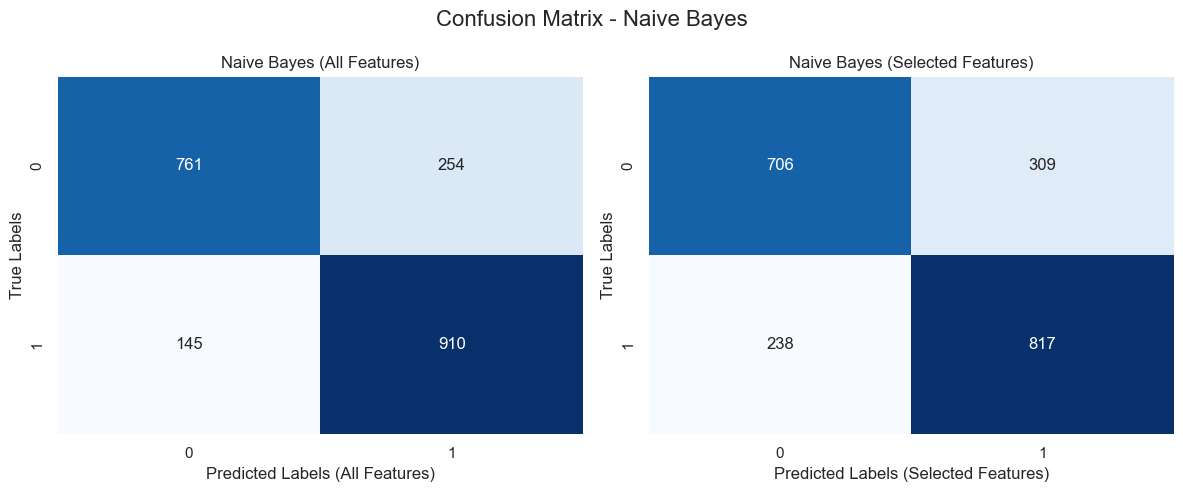

Cross-Validation Scores (All Features): [0.78864734 0.79347826 0.79468599 0.82729469 0.82487923 0.79468599
 0.8031401  0.80193237 0.81015719 0.81378476]
Average Cross-Validation Score (All Features): 0.8052685920240202

Cross-Validation Scores (Selected Features): [0.71859903 0.71980676 0.72705314 0.75603865 0.75603865 0.73671498
 0.73550725 0.73429952 0.74727932 0.71946796]
Average Cross-Validation Score (Selected Features): 0.7350805250337346


In [69]:
# Creating Naive Bayes model with all features
naiveb_all = GaussianNB()
naiveb_all.fit(X_train_all_fea_std, y_train_all_fea)

# Making prediction
NB_y_pred_all = naiveb_all.predict(X_test_all_fea_std)

NB_accuracy_all = accuracy_score(y_test_all_fea, NB_y_pred_all)
NB_precision_all = precision_score(y_test_all_fea, NB_y_pred_all)
NB_recall_all = recall_score(y_test_all_fea, NB_y_pred_all)
NB_f1_all = f1_score(y_test_all_fea, NB_y_pred_all)


# Creating Naive Bayes model with selected features
naiveb_selected = GaussianNB()
naiveb_selected.fit(X_train_sel_fea_std, y_train_sel_fea)

# Making prediction
NB_y_pred_sel = naiveb_selected.predict(X_test_sel_fea_std)

NB_accuracy_sel = accuracy_score(y_test_sel_fea, NB_y_pred_sel)
NB_precision_sel = precision_score(y_test_sel_fea, NB_y_pred_sel)
NB_recall_sel = recall_score(y_test_sel_fea, NB_y_pred_sel)
NB_f1_sel = f1_score(y_test_sel_fea, NB_y_pred_sel)

# Print the results
print("\033[1mNaive Bayes Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {NB_accuracy_all:.2f}")
print(f"Precision with all features: {NB_precision_all:.2f}")
print(f"Recall with all features: {NB_recall_all:.2f}")
print(f"F1-Score with all features: {NB_f1_all:.2f}")

print("\n")

print(f"Accuracy with selected features: {NB_accuracy_sel:.2f}")
print(f"Precision with selected features: {NB_precision_sel:.2f}")
print(f"Recall with selected features: {NB_recall_sel:.2f}")
print(f"F1-Score with selected features: {NB_f1_sel:.2f}")


#show the confusion matrix of both models
NB_conf_matrix_all = confusion_matrix(y_test_all_fea, NB_y_pred_all)
NB_conf_matrix_sel = confusion_matrix(y_test_sel_fea, NB_y_pred_sel)

# Plotting both confusion matrices side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(NB_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Naive Bayes (All Features)')

plt.subplot(1, 2, 2)
sns.heatmap(NB_conf_matrix_sel, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (Selected Features)')
plt.ylabel('True Labels')
plt.title('Naive Bayes (Selected Features)')

plt.suptitle('Confusion Matrix - Naive Bayes', fontsize=16)
plt.tight_layout()
plt.show()



#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
NB_cv_scores_all_features = cross_val_score(naiveb_all, X_train_all_fea, y_train_all_fea, cv=10, scoring='accuracy')

# Perform 10-fold cross-validation on the training data using selected features
NB_cv_scores_selected_features = cross_val_score(naiveb_selected, X_train_sel_fea, y_train_sel_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
NB_average_cv_score_all_features = NB_cv_scores_all_features.mean()
NB_average_cv_score_selected_features = NB_cv_scores_selected_features.mean()

print("Cross-Validation Scores (All Features):", NB_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", NB_average_cv_score_all_features)

print("\nCross-Validation Scores (Selected Features):", NB_cv_scores_selected_features)
print("Average Cross-Validation Score (Selected Features):", NB_average_cv_score_selected_features)



## Decision Trees  

Decision Trees Model Performance: 


Accuracy with all features: 0.81
Precision with all features: 0.82
Recall with all features: 0.80
F1-Score with all features: 0.81


Accuracy with selected features: 0.78
Precision with selected features: 0.79
Recall with selected features: 0.78
F1-Score with selected features: 0.79


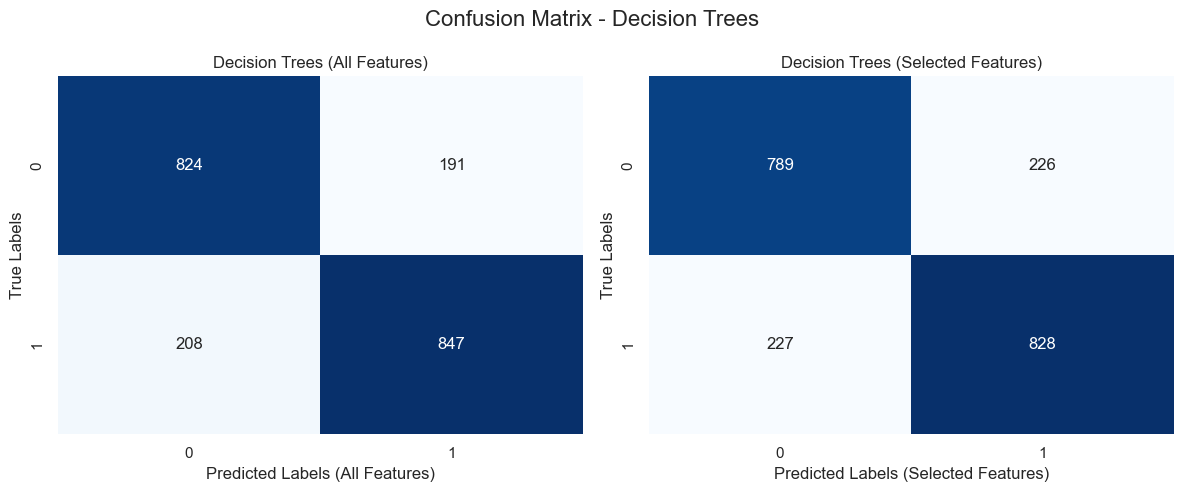

Cross-Validation Scores (All Features): [0.78743961 0.81400966 0.82487923 0.81884058 0.82246377 0.82004831
 0.82850242 0.81884058 0.80773881 0.83071342]
Average Cross-Validation Score (All Features): 0.8173476391590582

Cross-Validation Scores (Selected Features): [0.78140097 0.7910628  0.79227053 0.77173913 0.79468599 0.76086957
 0.79951691 0.76207729 0.78113664 0.77992745]
Average Cross-Validation Score (Selected Features): 0.7814687275467465


In [70]:
# Creating Decision Trees model with all features
DT_all = DecisionTreeClassifier(random_state=42)
DT_all.fit(X_train_all_fea_std, y_train_all_fea)

# Making prediction
DT_y_pred_all = DT_all.predict(X_test_all_fea_std)

DT_accuracy_all = accuracy_score(y_test_all_fea, DT_y_pred_all)
DT_precision_all = precision_score(y_test_all_fea, DT_y_pred_all)
DT_recall_all = recall_score(y_test_all_fea, DT_y_pred_all)
DT_f1_all = f1_score(y_test_all_fea, DT_y_pred_all)



# Creating Decision Trees model with selected features
DT_selected = DecisionTreeClassifier(random_state=42)
DT_selected.fit(X_train_sel_fea_std, y_train_sel_fea)

# Making prediction
DT_y_pred_sel = DT_selected.predict(X_test_sel_fea_std)

DT_accuracy_sel = accuracy_score(y_test_sel_fea, DT_y_pred_sel)
DT_precision_sel = precision_score(y_test_sel_fea, DT_y_pred_sel)
DT_recall_sel = recall_score(y_test_sel_fea, DT_y_pred_sel)
DT_f1_sel = f1_score(y_test_sel_fea, DT_y_pred_sel)

# Print the results
print("\033[1mDecision Trees Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {DT_accuracy_all:.2f}")
print(f"Precision with all features: {DT_precision_all:.2f}")
print(f"Recall with all features: {DT_recall_all:.2f}")
print(f"F1-Score with all features: {DT_f1_all:.2f}")

print("\n")

print(f"Accuracy with selected features: {DT_accuracy_sel:.2f}")
print(f"Precision with selected features: {DT_precision_sel:.2f}")
print(f"Recall with selected features: {DT_recall_sel:.2f}")
print(f"F1-Score with selected features: {DT_f1_sel:.2f}")


#show the confusion matrix of both models
DT_conf_matrix_all = confusion_matrix(y_test_all_fea, DT_y_pred_all)
DT_conf_matrix_sel = confusion_matrix(y_test_sel_fea, DT_y_pred_sel)

# Plotting both confusion matrices side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(DT_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Decision Trees (All Features)')

plt.subplot(1, 2, 2)
sns.heatmap(DT_conf_matrix_sel, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (Selected Features)')
plt.ylabel('True Labels')
plt.title('Decision Trees (Selected Features)')

plt.suptitle('Confusion Matrix - Decision Trees', fontsize=16)
plt.tight_layout()
plt.show()



#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
DT_cv_scores_all_features = cross_val_score(DT_all, X_train_all_fea, y_train_all_fea, cv=10, scoring='accuracy')

# Perform 10-fold cross-validation on the training data using selected features
DT_cv_scores_selected_features = cross_val_score(DT_selected, X_train_sel_fea, y_train_sel_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
DT_average_cv_score_all_features = DT_cv_scores_all_features.mean()
DT_average_cv_score_selected_features = DT_cv_scores_selected_features.mean()

print("Cross-Validation Scores (All Features):", DT_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", DT_average_cv_score_all_features)

print("\nCross-Validation Scores (Selected Features):", DT_cv_scores_selected_features)
print("Average Cross-Validation Score (Selected Features):", DT_average_cv_score_selected_features)


## Random Forest

Random Forest Model Performance: 


Accuracy with all features: 0.86
Precision with all features: 0.87
Recall with all features: 0.85
F1-Score with all features: 0.86


Accuracy with selected features: 0.81
Precision with selected features: 0.81
Recall with selected features: 0.82
F1-Score with selected features: 0.81


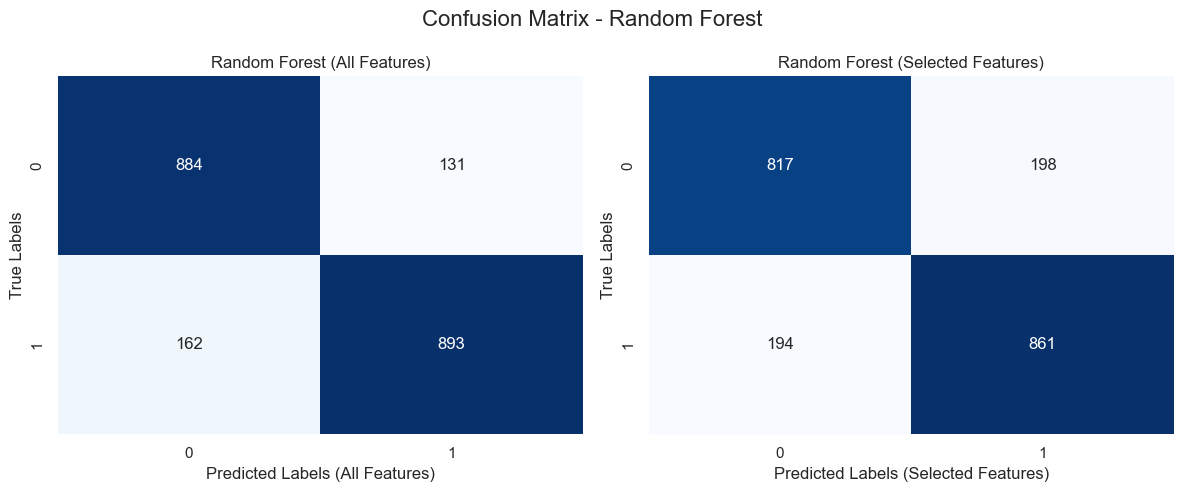

Cross-Validation Scores (All Features): [0.85507246 0.84541063 0.85628019 0.86231884 0.86714976 0.85990338
 0.85869565 0.85386473 0.85610641 0.86215236]
Average Cross-Validation Score (All Features): 0.8576954418800273

Cross-Validation Scores (Selected Features): [0.80193237 0.81400966 0.83091787 0.81763285 0.82487923 0.7910628
 0.80193237 0.81038647 0.79685611 0.80652963]
Average Cross-Validation Score (Selected Features): 0.809613935474826


In [71]:
# Creating Random Forest model with all features
RF_all = RandomForestClassifier(random_state=42)
RF_all.fit(X_train_all_fea_std, y_train_all_fea)

# Making prediction
RF_y_pred_all = RF_all.predict(X_test_all_fea_std)

RF_accuracy_all = accuracy_score(y_test_all_fea, RF_y_pred_all)
RF_precision_all = precision_score(y_test_all_fea, RF_y_pred_all)
RF_recall_all = recall_score(y_test_all_fea, RF_y_pred_all)
RF_f1_all = f1_score(y_test_all_fea, RF_y_pred_all)


# Creating Random Forest model with selected features
RF_selected = RandomForestClassifier(random_state=42)
RF_selected.fit(X_train_sel_fea_std, y_train_sel_fea)

# Making prediction
RF_y_pred_sel = RF_selected.predict(X_test_sel_fea_std)

RF_accuracy_sel = accuracy_score(y_test_sel_fea, RF_y_pred_sel)
RF_precision_sel = precision_score(y_test_sel_fea, RF_y_pred_sel)
RF_recall_sel = recall_score(y_test_sel_fea, RF_y_pred_sel)
RF_f1_sel = f1_score(y_test_sel_fea, RF_y_pred_sel)

# Print the results
print("\033[1mRandom Forest Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {RF_accuracy_all:.2f}")
print(f"Precision with all features: {RF_precision_all:.2f}")
print(f"Recall with all features: {RF_recall_all:.2f}")
print(f"F1-Score with all features: {RF_f1_all:.2f}")

print("\n")

print(f"Accuracy with selected features: {RF_accuracy_sel:.2f}")
print(f"Precision with selected features: {RF_precision_sel:.2f}")
print(f"Recall with selected features: {RF_recall_sel:.2f}")
print(f"F1-Score with selected features: {RF_f1_sel:.2f}")


#show the confusion matrix of both models
RF_conf_matrix_all = confusion_matrix(y_test_all_fea, RF_y_pred_all)
RF_conf_matrix_sel = confusion_matrix(y_test_sel_fea, RF_y_pred_sel)

# Plotting both confusion matrices side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(RF_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Random Forest (All Features)')

plt.subplot(1, 2, 2)
sns.heatmap(RF_conf_matrix_sel, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (Selected Features)')
plt.ylabel('True Labels')
plt.title('Random Forest (Selected Features)')

plt.suptitle('Confusion Matrix - Random Forest', fontsize=16)
plt.tight_layout()
plt.show()



#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
RF_cv_scores_all_features = cross_val_score(RF_all, X_train_all_fea, y_train_all_fea, cv=10, scoring='accuracy')

# Perform 10-fold cross-validation on the training data using selected features
RF_cv_scores_selected_features = cross_val_score(RF_selected, X_train_sel_fea, y_train_sel_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
RF_average_cv_score_all_features = RF_cv_scores_all_features.mean()
RF_average_cv_score_selected_features = RF_cv_scores_selected_features.mean()

print("Cross-Validation Scores (All Features):", RF_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", RF_average_cv_score_all_features)

print("\nCross-Validation Scores (Selected Features):", RF_cv_scores_selected_features)
print("Average Cross-Validation Score (Selected Features):", RF_average_cv_score_selected_features)


## Support Vector Machines (SVM)

Support Vector Machines (SVM) Model Performance: 


Accuracy with all features: 0.85
Precision with all features: 0.88
Recall with all features: 0.82
F1-Score with all features: 0.85


Accuracy with selected features: 0.78
Precision with selected features: 0.77
Recall with selected features: 0.82
F1-Score with selected features: 0.79


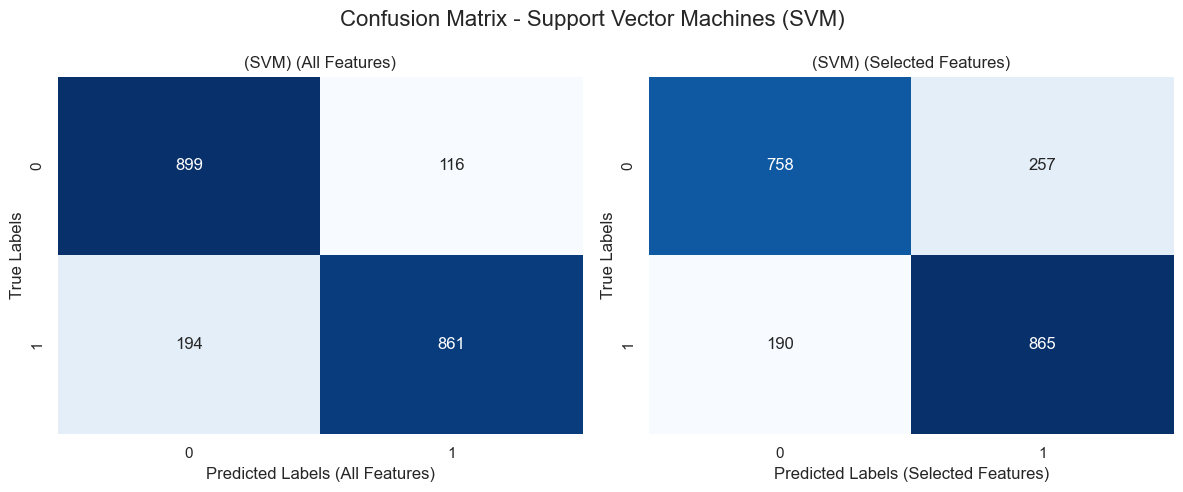

Cross-Validation Scores (All Features): [0.63164251 0.66062802 0.65942029 0.67391304 0.66545894 0.6352657
 0.66908213 0.64613527 0.65779927 0.66384522]
Average Cross-Validation Score (All Features): 0.6563190391906021

Cross-Validation Scores (Selected Features): [0.74637681 0.73671498 0.7294686  0.76690821 0.73671498 0.7173913
 0.74396135 0.72101449 0.74607013 0.73276904]
Average Cross-Validation Score (Selected Features): 0.7377389902388588


In [72]:
# Creating Support Vector Machines (SVM) model with all features
SVM_all = SVC(random_state=42)
SVM_all.fit(X_train_all_fea_std, y_train_all_fea)

# Making prediction
SVM_y_pred_all = SVM_all.predict(X_test_all_fea_std)

SVM_accuracy_all = accuracy_score(y_test_all_fea, SVM_y_pred_all)
SVM_precision_all = precision_score(y_test_all_fea, SVM_y_pred_all)
SVM_recall_all = recall_score(y_test_all_fea, SVM_y_pred_all)
SVM_f1_all = f1_score(y_test_all_fea, SVM_y_pred_all)


# Creating Support Vector Machines (SVM) model with selected features
SVM_selected = SVC(random_state=42)
SVM_selected.fit(X_train_sel_fea_std, y_train_sel_fea)

# Making prediction
SVM_y_pred_sel = SVM_selected.predict(X_test_sel_fea_std)

SVM_accuracy_sel = accuracy_score(y_test_sel_fea, SVM_y_pred_sel)
SVM_precision_sel = precision_score(y_test_sel_fea, SVM_y_pred_sel)
SVM_recall_sel = recall_score(y_test_sel_fea, SVM_y_pred_sel)
SVM_f1_sel = f1_score(y_test_sel_fea, SVM_y_pred_sel)

# Print the results
print("\033[1mSupport Vector Machines (SVM) Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {SVM_accuracy_all:.2f}")
print(f"Precision with all features: {SVM_precision_all:.2f}")
print(f"Recall with all features: {SVM_recall_all:.2f}")
print(f"F1-Score with all features: {SVM_f1_all:.2f}")

print("\n")

print(f"Accuracy with selected features: {SVM_accuracy_sel:.2f}")
print(f"Precision with selected features: {SVM_precision_sel:.2f}")
print(f"Recall with selected features: {SVM_recall_sel:.2f}")
print(f"F1-Score with selected features: {SVM_f1_sel:.2f}")


#show the confusion matrix of both models
SVM_conf_matrix_all = confusion_matrix(y_test_all_fea, SVM_y_pred_all)
SVM_conf_matrix_sel = confusion_matrix(y_test_sel_fea, SVM_y_pred_sel)

# Plotting both confusion matrices side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(SVM_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('(SVM) (All Features)')

plt.subplot(1, 2, 2)
sns.heatmap(SVM_conf_matrix_sel, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (Selected Features)')
plt.ylabel('True Labels')
plt.title('(SVM) (Selected Features)')

plt.suptitle('Confusion Matrix - Support Vector Machines (SVM)', fontsize=16)
plt.tight_layout()
plt.show()



#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
SVM_cv_scores_all_features = cross_val_score(SVM_all, X_train_all_fea, y_train_all_fea, cv=10, scoring='accuracy')

# Perform 10-fold cross-validation on the training data using selected features
SVM_cv_scores_selected_features = cross_val_score(SVM_selected, X_train_sel_fea, y_train_sel_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
SVM_average_cv_score_all_features = SVM_cv_scores_all_features.mean()
SVM_average_cv_score_selected_features = SVM_cv_scores_selected_features.mean()

print("Cross-Validation Scores (All Features):", SVM_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", SVM_average_cv_score_all_features)

print("\nCross-Validation Scores (Selected Features):", SVM_cv_scores_selected_features)
print("Average Cross-Validation Score (Selected Features):", SVM_average_cv_score_selected_features)


## K-Nearest Neighbors (k-NN)

K-Nearest Neighbors (k-NN) Model Performance: 


Accuracy with all features: 0.83
Precision with all features: 0.83
Recall with all features: 0.83
F1-Score with all features: 0.83


Accuracy with selected features: 0.78
Precision with selected features: 0.77
Recall with selected features: 0.83
F1-Score with selected features: 0.80


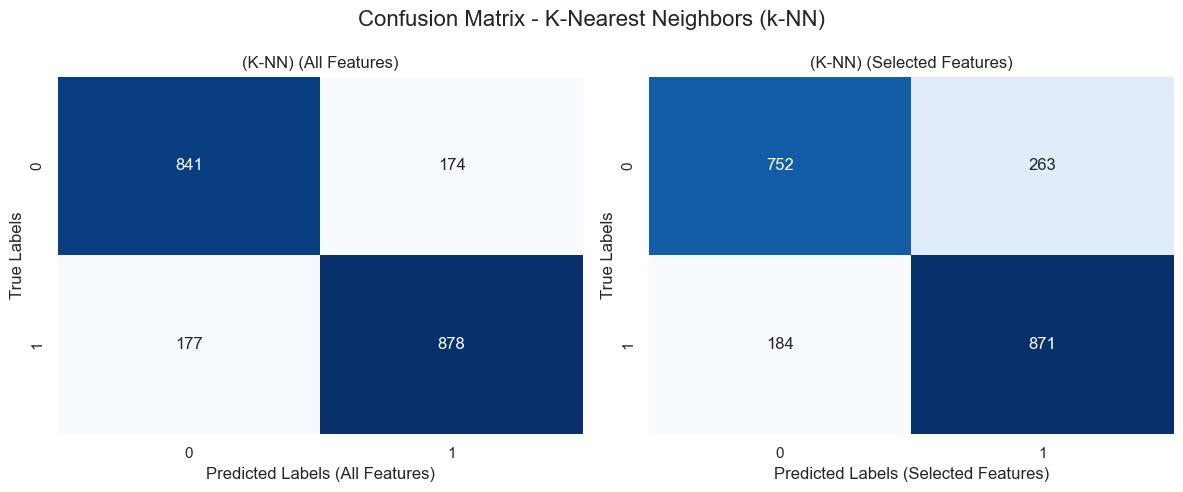

Cross-Validation Scores (All Features): [0.76811594 0.76328502 0.78140097 0.77415459 0.78140097 0.74879227
 0.75966184 0.75724638 0.75453446 0.76420798]
Average Cross-Validation Score (All Features): 0.7652800413577975

Cross-Validation Scores (Selected Features): [0.77173913 0.78743961 0.80193237 0.8031401  0.77536232 0.7826087
 0.78864734 0.75362319 0.77509069 0.77629988]
Average Cross-Validation Score (Selected Features): 0.7815883321942414


In [73]:
# Creating K-Nearest Neighbors (k-NN) model with all features

# number of neighbors is 5
KNN_all = KNeighborsClassifier(n_neighbors=5) 
KNN_all.fit(X_train_all_fea_std, y_train_all_fea)

# Making prediction
KNN_y_pred_all = KNN_all.predict(X_test_all_fea_std)

KNN_accuracy_all = accuracy_score(y_test_all_fea, KNN_y_pred_all)
KNN_precision_all = precision_score(y_test_all_fea, KNN_y_pred_all)
KNN_recall_all = recall_score(y_test_all_fea, KNN_y_pred_all)
KNN_f1_all = f1_score(y_test_all_fea, KNN_y_pred_all)


# Creating K-Nearest Neighbors (k-NN) model with selected features
KNN_selected = KNeighborsClassifier(n_neighbors=5) 
KNN_selected.fit(X_train_sel_fea_std, y_train_sel_fea)

# Making prediction
KNN_y_pred_sel = KNN_selected.predict(X_test_sel_fea_std)

KNN_accuracy_sel = accuracy_score(y_test_sel_fea, KNN_y_pred_sel)
KNN_precision_sel = precision_score(y_test_sel_fea, KNN_y_pred_sel)
KNN_recall_sel = recall_score(y_test_sel_fea, KNN_y_pred_sel)
KNN_f1_sel = f1_score(y_test_sel_fea, KNN_y_pred_sel)


# Print the results
print("\033[1mK-Nearest Neighbors (k-NN) Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {KNN_accuracy_all:.2f}")
print(f"Precision with all features: {KNN_precision_all:.2f}")
print(f"Recall with all features: {KNN_recall_all:.2f}")
print(f"F1-Score with all features: {KNN_f1_all:.2f}")

print("\n")

print(f"Accuracy with selected features: {KNN_accuracy_sel:.2f}")
print(f"Precision with selected features: {KNN_precision_sel:.2f}")
print(f"Recall with selected features: {KNN_recall_sel:.2f}")
print(f"F1-Score with selected features: {KNN_f1_sel:.2f}")



#show the confusion matrix of both models
KNN_conf_matrix_all = confusion_matrix(y_test_all_fea, KNN_y_pred_all)
KNN_conf_matrix_sel = confusion_matrix(y_test_sel_fea, KNN_y_pred_sel)

# Plotting both confusion matrices side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(KNN_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('(K-NN) (All Features)')

plt.subplot(1, 2, 2)
sns.heatmap(KNN_conf_matrix_sel, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (Selected Features)')
plt.ylabel('True Labels')
plt.title('(K-NN) (Selected Features)')

plt.suptitle('Confusion Matrix - K-Nearest Neighbors (k-NN)', fontsize=16)
plt.tight_layout()
plt.show()



#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
KNN_cv_scores_all_features = cross_val_score(KNN_all, X_train_all_fea, y_train_all_fea, cv=10, scoring='accuracy')

# Perform 10-fold cross-validation on the training data using selected features
KNN_cv_scores_selected_features = cross_val_score(KNN_selected, X_train_sel_fea, y_train_sel_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
KNN_average_cv_score_all_features = KNN_cv_scores_all_features.mean()
KNN_average_cv_score_selected_features = KNN_cv_scores_selected_features.mean()

print("Cross-Validation Scores (All Features):", KNN_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", KNN_average_cv_score_all_features)

print("\nCross-Validation Scores (Selected Features):", KNN_cv_scores_selected_features)
print("Average Cross-Validation Score (Selected Features):", KNN_average_cv_score_selected_features)



## Gradient Boosting 

Gradient Boosting Model Performance: 


Accuracy with all features: 0.87
Precision with all features: 0.87
Recall with all features: 0.87
F1-Score with all features: 0.87


Accuracy with selected features: 0.80
Precision with selected features: 0.77
Recall with selected features: 0.85
F1-Score with selected features: 0.81


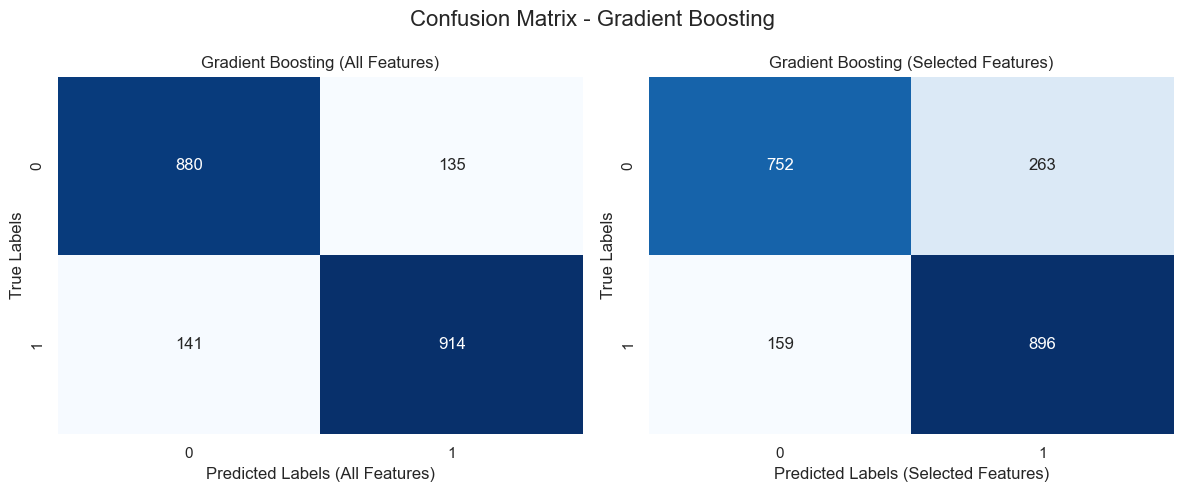

Cross-Validation Scores (All Features): [0.852657   0.84903382 0.8647343  0.87922705 0.87198068 0.86835749
 0.8647343  0.84782609 0.87182588 0.86698912]
Average Cross-Validation Score (All Features): 0.8637365718591733

Cross-Validation Scores (Selected Features): [0.77536232 0.77777778 0.77898551 0.79710145 0.78140097 0.77536232
 0.78502415 0.77898551 0.80290206 0.77509069]
Average Cross-Validation Score (Selected Features): 0.7827992744860943


In [74]:
# Creating Gradient Boosting model with all features
GB_all = GradientBoostingClassifier(random_state=42)
GB_all.fit(X_train_all_fea_std, y_train_all_fea)

# Making prediction
GB_y_pred_all = GB_all.predict(X_test_all_fea_std)

GB_accuracy_all = accuracy_score(y_test_all_fea, GB_y_pred_all)
GB_precision_all = precision_score(y_test_all_fea, GB_y_pred_all)
GB_recall_all = recall_score(y_test_all_fea, GB_y_pred_all)
GB_f1_all = f1_score(y_test_all_fea, GB_y_pred_all)


# Creating Gradient Boosting model with selected features
GB_selected = GradientBoostingClassifier(random_state=42)
GB_selected.fit(X_train_sel_fea_std, y_train_sel_fea)

# Making prediction
GB_y_pred_sel = GB_selected.predict(X_test_sel_fea_std)

GB_accuracy_sel = accuracy_score(y_test_sel_fea, GB_y_pred_sel)
GB_precision_sel = precision_score(y_test_sel_fea, GB_y_pred_sel)
GB_recall_sel = recall_score(y_test_sel_fea, GB_y_pred_sel)
GB_f1_sel = f1_score(y_test_sel_fea, GB_y_pred_sel)

# Print the results
print("\033[1mGradient Boosting Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {GB_accuracy_all:.2f}")
print(f"Precision with all features: {GB_precision_all:.2f}")
print(f"Recall with all features: {GB_recall_all:.2f}")
print(f"F1-Score with all features: {GB_f1_all:.2f}")

print("\n")

print(f"Accuracy with selected features: {GB_accuracy_sel:.2f}")
print(f"Precision with selected features: {GB_precision_sel:.2f}")
print(f"Recall with selected features: {GB_recall_sel:.2f}")
print(f"F1-Score with selected features: {GB_f1_sel:.2f}")


#show the confusion matrix of both models
GB_conf_matrix_all = confusion_matrix(y_test_all_fea, GB_y_pred_all)
GB_conf_matrix_sel = confusion_matrix(y_test_sel_fea, GB_y_pred_sel)

# Plotting both confusion matrices side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(GB_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Gradient Boosting (All Features)')

plt.subplot(1, 2, 2)
sns.heatmap(GB_conf_matrix_sel, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (Selected Features)')
plt.ylabel('True Labels')
plt.title('Gradient Boosting (Selected Features)')

plt.suptitle('Confusion Matrix - Gradient Boosting', fontsize=16)
plt.tight_layout()
plt.show()



#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
GB_cv_scores_all_features = cross_val_score(GB_all, X_train_all_fea, y_train_all_fea, cv=10, scoring='accuracy')

# Perform 10-fold cross-validation on the training data using selected features
GB_cv_scores_selected_features = cross_val_score(GB_selected, X_train_sel_fea, y_train_sel_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
GB_average_cv_score_all_features = GB_cv_scores_all_features.mean()
GB_average_cv_score_selected_features = GB_cv_scores_selected_features.mean()

print("Cross-Validation Scores (All Features):", GB_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", GB_average_cv_score_all_features)

print("\nCross-Validation Scores (Selected Features):", GB_cv_scores_selected_features)
print("Average Cross-Validation Score (Selected Features):", GB_average_cv_score_selected_features)



# Deep Learning Algorithms

## ANN 

In [75]:
len(X_train_all_fea.columns)

46

In [76]:
# defining the Sequential model
model = keras.Sequential([
    #input layer
    keras.layers.Dense(46, input_shape=(46,), activation='relu'),
    #output layer
    keras.layers.Dense(1, activation='sigmoid'),
])

# Compiling the model
model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])

model.fit(X_train_all_fea_std, y_train_all_fea, epochs=60)

Epoch 1/60
259/259 [==============================] - 2s 3ms/step - loss: 0.4105 - accuracy: 0.8037
Epoch 2/60
259/259 [==============================] - 1s 3ms/step - loss: 0.3126 - accuracy: 0.8553
Epoch 3/60
259/259 [==============================] - 1s 3ms/step - loss: 0.2959 - accuracy: 0.8611
Epoch 4/60
259/259 [==============================] - 1s 3ms/step - loss: 0.2884 - accuracy: 0.8635
Epoch 5/60
259/259 [==============================] - 1s 2ms/step - loss: 0.2828 - accuracy: 0.8691
Epoch 6/60
259/259 [==============================] - 1s 2ms/step - loss: 0.2799 - accuracy: 0.8660
Epoch 7/60
259/259 [==============================] - 1s 3ms/step - loss: 0.2781 - accuracy: 0.8687
Epoch 8/60
259/259 [==============================] - 1s 2ms/step - loss: 0.2745 - accuracy: 0.8716
Epoch 9/60
259/259 [==============================] - 1s 2ms/step - loss: 0.2719 - accuracy: 0.8705
Epoch 10/60
259/259 [==============================] - 1s 3ms/step - loss: 0.2711 - accuracy: 0.8735

In [77]:
ANN_eval_results = model.evaluate(X_train_all_fea_std,y_train_all_fea)
accuracy_index = 1
ANN_accuracy = ANN_eval_results[accuracy_index]
print(f"Accuracy: {ANN_accuracy:.2f}")

259/259 [==============================] - 1s 2ms/step - loss: 0.2315 - accuracy: 0.8948
Accuracy: 0.89


In [78]:
y_pred = model.predict(X_test_all_fea_std)
y_pred_binary = (y_pred > 0.5)

ANN_precision = precision_score(y_test_all_fea, y_pred_binary)
ANN_recall = recall_score(y_test_all_fea, y_pred_binary)
ANN_f1 = f1_score(y_test_all_fea, y_pred_binary)

print("Precision:", ANN_precision)
print("Recall:", ANN_recall)
print("F1-score:", ANN_f1)

65/65 [==============================] - 0s 2ms/step
Precision: 0.8655544651619235
Recall: 0.8360189573459715
F1-score: 0.8505303760848602


### CNN 

In [79]:
# Create a Sequential model
cnn_model = Sequential()

# Adding Convolutional layer with max pooling
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_all_fea_std.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=2))

# Adding a Flatten layer
cnn_model.add(Flatten())

# Adding fully connected layers
cnn_model.add(Dense(46, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))  # Binary classification output

# Compile the model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.fit(X_train_all_fea_std, y_train_all_fea, epochs=55)

# model evalution
loss, accuracy = cnn_model.evaluate(X_test_all_fea_std, y_test_all_fea)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")


Epoch 1/55
259/259 [==============================] - 2s 5ms/step - loss: 0.3444 - accuracy: 0.8356
Epoch 2/55
259/259 [==============================] - 1s 5ms/step - loss: 0.3107 - accuracy: 0.8513
Epoch 3/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2974 - accuracy: 0.8611
Epoch 4/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2941 - accuracy: 0.8594
Epoch 5/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2947 - accuracy: 0.8589
Epoch 6/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2920 - accuracy: 0.8619
Epoch 7/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2871 - accuracy: 0.8602
Epoch 8/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2863 - accuracy: 0.8628
Epoch 9/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2861 - accuracy: 0.8606
Epoch 10/55
259/259 [==============================] - 1s 5ms/step - loss: 0.2829 - accuracy: 0.8654

In [80]:
CNN_eval_results = cnn_model.evaluate(X_train_all_fea_std,y_train_all_fea)
accuracy_index = 1
CNN_accuracy = CNN_eval_results[accuracy_index]
print(f"Accuracy: {CNN_accuracy:.2f}")

259/259 [==============================] - 1s 3ms/step - loss: 0.2292 - accuracy: 0.8924
Accuracy: 0.89


In [81]:
y_pred_cnn = cnn_model.predict(X_test_all_fea_std)
y_pred_binary_cnn = (y_pred_cnn > 0.5)

CNN_precision = precision_score(y_test_all_fea, y_pred_binary_cnn)
CNN_recall = recall_score(y_test_all_fea, y_pred_binary_cnn)
CNN_f1 = f1_score(y_test_all_fea, y_pred_binary_cnn)

print("Precision:", CNN_precision)
print("Recall:", CNN_recall)
print("F1-score:", CNN_f1)

65/65 [==============================] - 0s 3ms/step
Precision: 0.869351669941061
Recall: 0.8388625592417062
F1-score: 0.8538350217076701


### Performance Metrics Comparison between best Machine learning and Deep Learning Models

#### All Features 

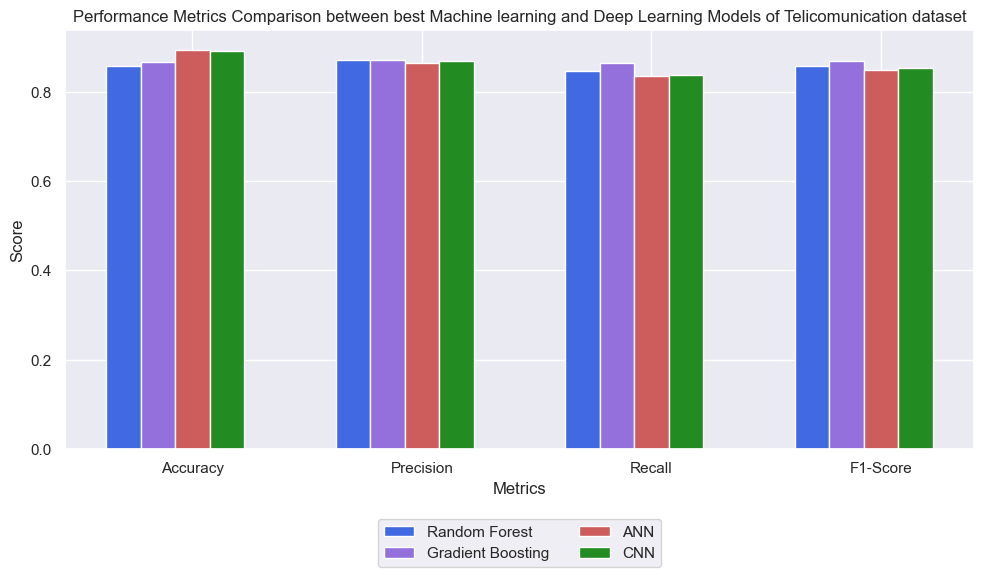

In [82]:
classifiers = ["Random Forest", "Gradient Boosting", "ANN", "CNN"]
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

Random_Forest = [RF_accuracy_all, RF_precision_all, RF_recall_all, RF_f1_all]
Gradient_Boosting = [GB_accuracy_all, GB_precision_all, GB_recall_all, GB_f1_all]
ANN = [ANN_accuracy, ANN_precision, ANN_recall, ANN_f1]
CNN = [CNN_accuracy, CNN_precision, CNN_recall, CNN_f1]

data = [
    Random_Forest, Gradient_Boosting, ANN, CNN
]

num_classifiers = len(classifiers)
num_metrics = len(metrics)
bar_width = 0.15  
index = np.arange(num_metrics)

# Creating a list of colors
blue_colors = ['#4169E1', '#9370DB', '#CD5C5C', '#228B22']

fig, ax = plt.subplots(figsize=(10, 6))

for i, classifier in enumerate(classifiers):
    classifier_values = data[i]
    ax.bar(index + i * bar_width, classifier_values, bar_width, color=blue_colors[i], label=classifier)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics Comparison between best Machine learning and Deep Learning Models of Telicomunication dataset')
ax.set_xticks(index + (num_classifiers / 2) * bar_width)
ax.set_xticklabels(metrics)

# Placing the legend (models name) at the bottom in two lines
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()


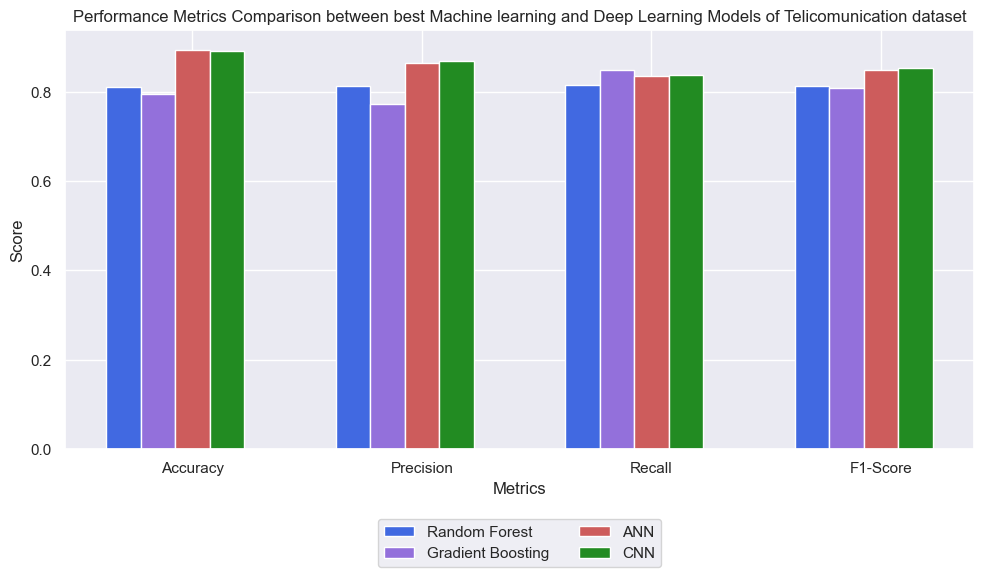

In [83]:
classifiers = ["Random Forest", "Gradient Boosting", "ANN", "CNN"]
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

Random_Forest = [RF_accuracy_sel, RF_precision_sel, RF_recall_sel, RF_f1_sel]
Gradient_Boosting = [GB_accuracy_sel, GB_precision_sel, GB_recall_sel, GB_f1_sel]
ANN = [ANN_accuracy, ANN_precision, ANN_recall, ANN_f1]
CNN = [CNN_accuracy, CNN_precision, CNN_recall, CNN_f1]

data = [
    Random_Forest, Gradient_Boosting, ANN, CNN
]

num_classifiers = len(classifiers)
num_metrics = len(metrics)
bar_width = 0.15  
index = np.arange(num_metrics)

# Creating a list of colors
blue_colors = ['#4169E1', '#9370DB', '#CD5C5C', '#228B22']

fig, ax = plt.subplots(figsize=(10, 6))

for i, classifier in enumerate(classifiers):
    classifier_values = data[i]
    ax.bar(index + i * bar_width, classifier_values, bar_width, color=blue_colors[i], label=classifier)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics Comparison between best Machine learning and Deep Learning Models of Telicomunication dataset')
ax.set_xticks(index + (num_classifiers / 2) * bar_width)
ax.set_xticklabels(metrics)

# Placing the legend (models name) at the bottom in two lines
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()


# Applying same models on banking dataset

In [84]:
# reading the dataset
bank_df = pd.read_csv("C:/Users/Rizwan/Desktop/dissertation/dataset/Churn_Modelling.csv")

In [85]:
bank_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [86]:
bank_df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [87]:
#finding how many rows and columns we have in our dataset
bank_df.shape

(10000, 14)

In [88]:
#getting the data types of all columns in our dataset
bank_df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [89]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## Data Analysis 

In [90]:
bank_df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Finding Numerical Features 

In [91]:
#finding how many numerical columns we have in our dataset
bank_num_columns = [columns for columns in bank_df.columns if bank_df[columns].dtypes != 'O']

print('Number of Numerical Columns: ', len(bank_num_columns))

#getting numerical columns data 
bank_df[bank_num_columns].head()

Number of Numerical Columns:  11


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,699,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,850,43,2,125510.82,1,1,1,79084.10,0


### Finding Categorical Features 

In [92]:
#finding how many categorical columns we have in our dataset
bank_cat_columns=[columns for columns in bank_df.columns if bank_df[columns].dtypes=='O']

print('Number of Categorical Columns: ', len(bank_cat_columns))

#getting Categorical columns data 
bank_df[bank_cat_columns].head()

Number of Categorical Columns:  3


,Surname,Geography,Gender
0,Hargrave,France,Female
1,Hill,Spain,Female
2,Onio,France,Female
3,Boni,France,Female
4,Mitchell,Spain,Female


out of 14 columns we have 3 categorical columns and 11 numerical columns now lets find out how many unique values we have in each categorical columns 

In [93]:
#finding unique values in categorical columns
for columns in bank_cat_columns:
    print('column {} having number of categories are {}'.format(columns,len(bank_df[columns].unique())))

column Surname having number of categories are 2932
column Geography having number of categories are 3
column Gender having number of categories are 2


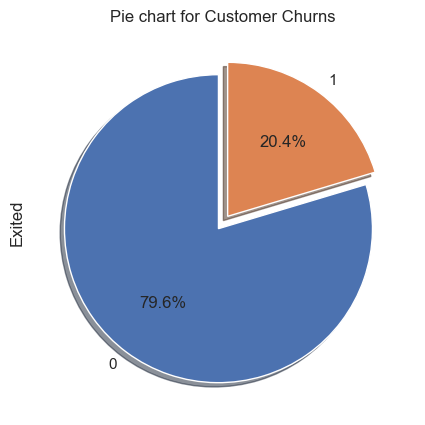

0    7963
1    2037
Name: Exited, dtype: int64

In [94]:
# findout how many churns we have in our dataset
bank_df['Exited'].value_counts().plot.pie(explode=[0.05,0.05], autopct = '%1.1f%%', startangle=90, shadow=True, figsize=(5,5))
plt.title('Pie chart for Customer Churns')
plt.show()

#total count of churners and non churners
bank_df['Exited'].value_counts()

0 means non churners

1 means churners

So out of 10000 customers 2037 customers are churners now we will analyze what are the main factors of customer

# Data Preprocessing 

In [95]:
# making a copy of dataframe
bank_df2 = bank_df.copy()

In [96]:
# dropping some columns which are not usefull
bank_drop_col = ['RowNumber','CustomerId','Surname']

bank_df2 = bank_df2.drop(columns=bank_drop_col,axis=1)

In [97]:
bank_df2.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

C:\Users\Rizwan\AppData\Local\Temp\ipykernel_14984\1296295062.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  b_correlation_matrix = bank_df2.corr()


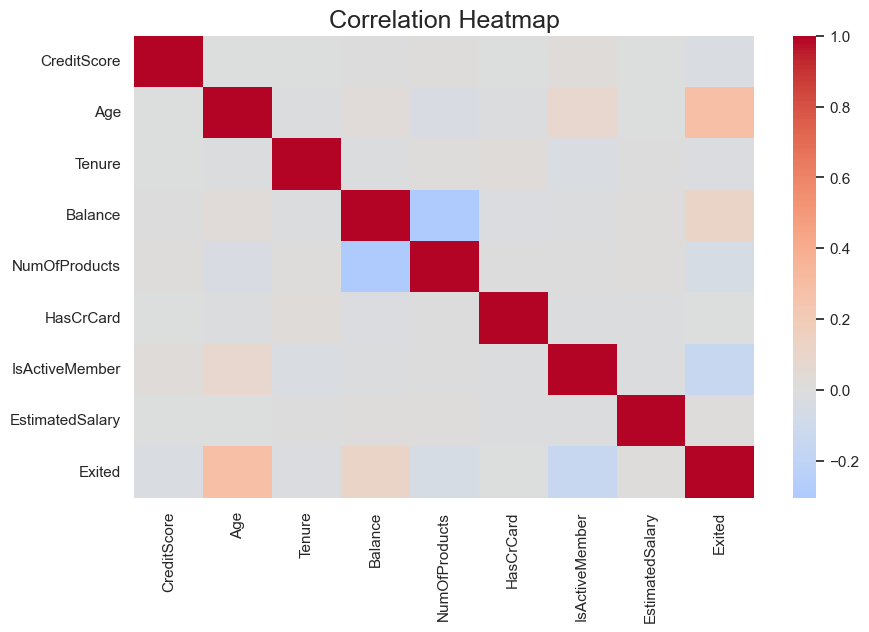

In [98]:
#making correlation heatmap
b_correlation_matrix = bank_df2.corr()

plt.figure(figsize=(10, 6)) 
heatmap = sns.heatmap(b_correlation_matrix, cmap='coolwarm', center=0)
heatmap.set_title("Correlation Heatmap", fontsize=18)  

plt.show()

### One-Hot Encoding  

In [99]:
# using one-hot encoding to convert the categorical data into numerical data

bank_cat_cols = ['Geography','Gender']


# using pd.get_dummies() for one-hot encoding
bank_encoded_cat_df = pd.get_dummies(bank_df2[bank_cat_cols])

# Drop the previous categorical columns
bank_df2 = bank_df2.drop(columns=bank_cat_cols)

bank_encoded_df2 = pd.concat([bank_encoded_cat_df, bank_df2], axis=1)

bank_encoded_df2.head()

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,0,0,1,0,619,42,2,0.00,1,1,1,101348.88,1
1,0,0,1,1,0,608,41,1,83807.86,1,0,1,112542.58,0
2,1,0,0,1,0,502,42,8,159660.80,3,1,0,113931.57,1
3,1,0,0,1,0,699,39,1,0.00,2,0,0,93826.63,0
4,0,0,1,1,0,850,43,2,125510.82,1,1,1,79084.10,0


In [100]:
bank_encoded_df2.shape

(10000, 14)

After one-hot encoding now we have 14 columns now its time to do a feature selection

# draw a heatmap

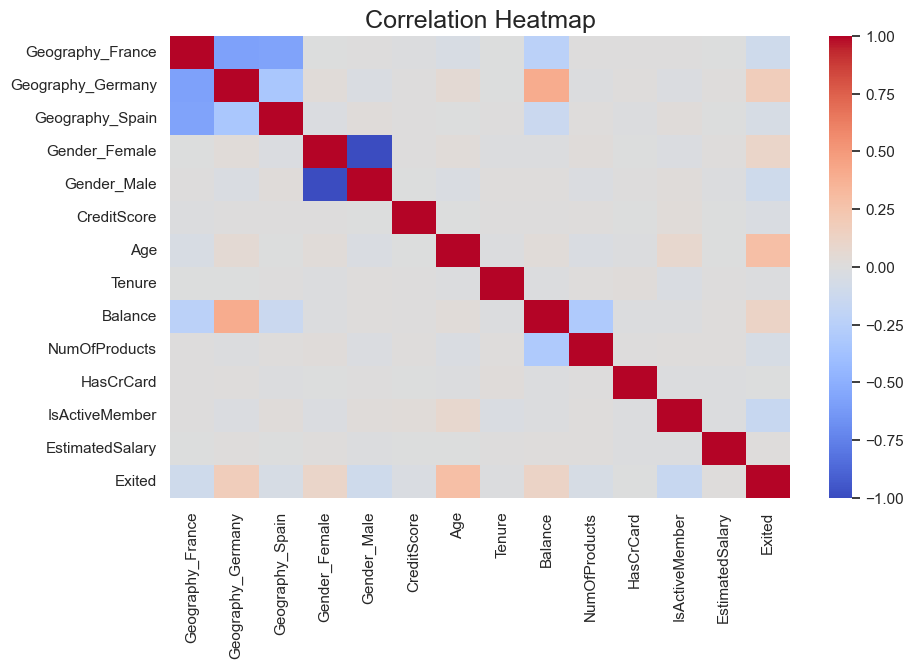

In [101]:
#making correlation heatmap
correlation_matrix = bank_encoded_df2.corr()

plt.figure(figsize=(10, 6)) 
heatmap = sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
heatmap.set_title("Correlation Heatmap", fontsize=18)  

plt.show()

## Handling imbalance Dataset with Over Sampling 

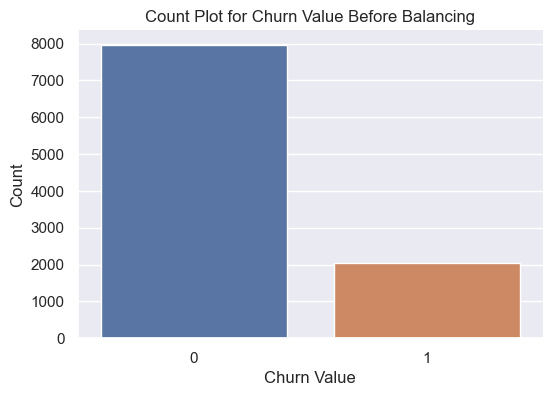

0    7963
1    2037
Name: Exited, dtype: int64

In [102]:
#lets plot the count plot to check the imbalance data
sns.set(style='darkgrid')
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=bank_df)
plt.title('Count Plot for Churn Value Before Balancing')
plt.xlabel('Churn Value')
plt.ylabel('Count')
sns.despine()
plt.show()


bank_df['Exited'].value_counts()

It can be seen that our data is imbalance as we have 7963 [0] values and 2037 [1] values we need to make it as a balance dataset for that will use random oversampling

In [103]:
bank_X = bank_encoded_df2.drop('Exited', axis='columns')
bank_y = bank_encoded_df2['Exited']

In [104]:
bank_y.value_counts()

0    7963
1    2037
Name: Exited, dtype: int64

In [105]:
# I use smote to balance the dataset
bank_smote = SMOTE(sampling_strategy='minority')
bank_X_balance_all, bank_y_balance_all = bank_smote.fit_resample(bank_X,bank_y)
bank_y_balance_all.value_counts()

1    7963
0    7963
Name: Exited, dtype: int64

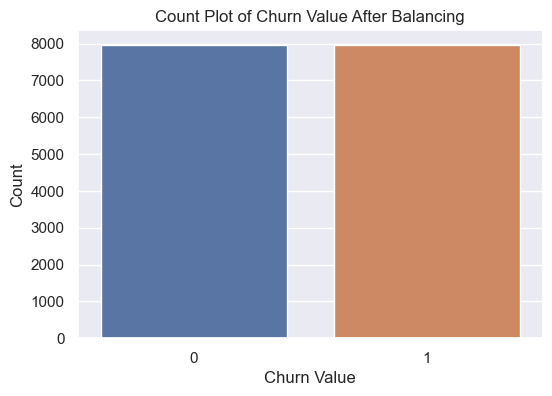

In [106]:
# plotting the count plot to see the churn values after balancing the dataset
sns.set(style='darkgrid')
plt.figure(figsize=(6, 4))
sns.countplot(x=bank_y_balance_all)
plt.xlabel('Churn Value')
plt.ylabel('Count')
plt.title('Count Plot of Churn Value After Balancing')
plt.show()

In [107]:
bank_X_balance_all.value_counts().sum()

15926

So now we have total 15926 records after balancing the dataset 

# Applying Machine Learning Algorithms

In [108]:
#Split the data into training and testing
bank_X_train_all_fea, bank_X_test_all_fea, bank_y_train_all_fea, bank_y_test_all_fea = train_test_split(bank_X_balance_all, bank_y_balance_all, test_size=0.2, random_state=42)

# Standardizing the features
bank_scaler_all_fea = StandardScaler()
bank_X_train_all_fea_std = bank_scaler_all_fea.fit_transform(bank_X_train_all_fea)
bank_X_test_all_fea_std = bank_scaler_all_fea.transform(bank_X_test_all_fea)


## logistic Regression 

Logistic Regression Model Performance: 


Accuracy with all features: 0.84
Precision with all features: 0.88
Recall with all features: 0.78
F1-Score with all features: 0.83




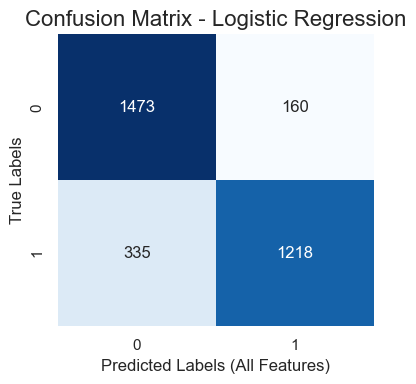

Cross-Validation Scores (All Features): [0.69544741 0.68288854 0.66640502 0.69623234 0.67346939 0.67032967
 0.67032967 0.68602826 0.67189953 0.69466248]
Average Cross-Validation Score (All Features): 0.6807692307692308


In [109]:
# Creating Logistic Regression model with all features
bank_log_model_all = LogisticRegression(random_state=42)
bank_log_model_all.fit(bank_X_train_all_fea_std, bank_y_train_all_fea)

bank_y_pred_all = bank_log_model_all.predict(bank_X_test_all_fea_std)

bank_accuracy_all = accuracy_score(bank_y_test_all_fea, bank_y_pred_all)
bank_precision_all = precision_score(bank_y_test_all_fea, bank_y_pred_all)
bank_recall_all = recall_score(bank_y_test_all_fea, bank_y_pred_all)
bank_f1_all = f1_score(bank_y_test_all_fea, bank_y_pred_all)



# Print the results
print("\033[1mLogistic Regression Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {bank_accuracy_all:.2f}")
print(f"Precision with all features: {bank_precision_all:.2f}")
print(f"Recall with all features: {bank_recall_all:.2f}")
print(f"F1-Score with all features: {bank_f1_all:.2f}")

print("\n")


#confusion matrix and ROC curve of the model
bank_conf_matrix_all = confusion_matrix(bank_y_test_all_fea, bank_y_pred_all)


plt.figure(figsize=(4, 4))
sns.heatmap(bank_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Logistic Regression', fontsize=16)

plt.tight_layout()
plt.show()


#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
bank_cv_scores_all_features = cross_val_score(bank_log_model_all, bank_X_train_all_fea, bank_y_train_all_fea, cv=10, scoring='accuracy')


# Calculate the average cross-validation scores
bank_average_cv_score_all_features = bank_cv_scores_all_features.mean()

print("Cross-Validation Scores (All Features):", bank_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", bank_average_cv_score_all_features)


## Naive Bayes  

Naive Bayes Model Performance: 


Accuracy with all features: 0.80
Precision with all features: 0.80
Recall with all features: 0.78
F1-Score with all features: 0.79




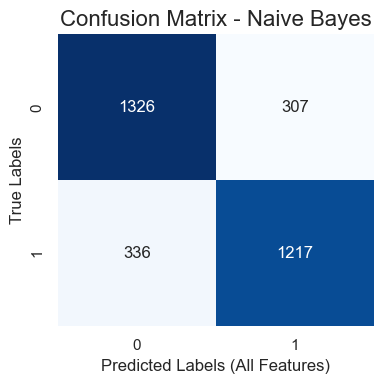

Cross-Validation Scores (All Features): [0.7166405  0.72841444 0.71899529 0.74646782 0.72291994 0.70565149
 0.7244898  0.71821036 0.71978022 0.73469388]
Average Cross-Validation Score (All Features): 0.7236263736263736


In [110]:
# Creating Naive Bayes model with all features
bank_naiveb_all = GaussianNB()
bank_naiveb_all.fit(bank_X_train_all_fea_std, bank_y_train_all_fea)

bank_NB_y_pred_all = bank_naiveb_all.predict(bank_X_test_all_fea_std)

bank_NB_accuracy_all = accuracy_score(bank_y_test_all_fea, bank_NB_y_pred_all)
bank_NB_precision_all = precision_score(bank_y_test_all_fea, bank_NB_y_pred_all)
bank_NB_recall_all = recall_score(bank_y_test_all_fea, bank_NB_y_pred_all)
bank_NB_f1_all = f1_score(bank_y_test_all_fea, bank_NB_y_pred_all)


# Print the results
print("\033[1mNaive Bayes Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {bank_NB_accuracy_all:.2f}")
print(f"Precision with all features: {bank_NB_precision_all:.2f}")
print(f"Recall with all features: {bank_NB_recall_all:.2f}")
print(f"F1-Score with all features: {bank_NB_f1_all:.2f}")

print("\n")


#confusion matrix of both models
bank_NB_conf_matrix_all = confusion_matrix(bank_y_test_all_fea, bank_NB_y_pred_all)

plt.figure(figsize=(4, 4))
sns.heatmap(bank_NB_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Naive Bayes', fontsize=16)


plt.tight_layout()
plt.show()



#Finding Cross validation Scores for both model

# Perform 10-fold cross-validation on the training data using all features
bank_NB_cv_scores_all_features = cross_val_score(bank_naiveb_all, bank_X_train_all_fea, bank_y_train_all_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
bank_NB_average_cv_score_all_features = bank_NB_cv_scores_all_features.mean()

print("Cross-Validation Scores (All Features):", bank_NB_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", bank_NB_average_cv_score_all_features)


## Decision Trees 

Decision Trees Model Performance: 


Accuracy with all features: 0.84
Precision with all features: 0.83
Recall with all features: 0.86
F1-Score with all features: 0.84




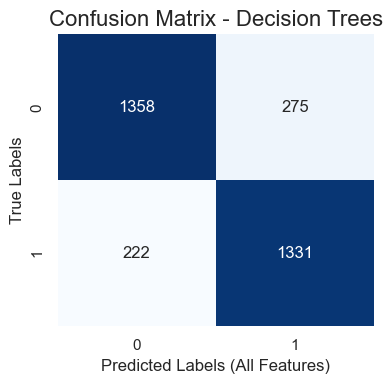

Cross-Validation Scores (All Features): [0.83281005 0.85792779 0.83830455 0.84536892 0.83045526 0.8477237
 0.86577708 0.83751962 0.83830455 0.84850863]
Average Cross-Validation Score (All Features): 0.8442700156985872


In [111]:
# Creating Decision Trees model with all features
bank_DT_all = DecisionTreeClassifier(random_state=42)
bank_DT_all.fit(bank_X_train_all_fea_std, bank_y_train_all_fea)

# Making prediction
bank_DT_y_pred_all = bank_DT_all.predict(bank_X_test_all_fea_std)

# Calculating accuracy
bank_DT_accuracy_all = accuracy_score(bank_y_test_all_fea, bank_DT_y_pred_all)
bank_DT_precision_all = precision_score(bank_y_test_all_fea, bank_DT_y_pred_all)
bank_DT_recall_all = recall_score(bank_y_test_all_fea, bank_DT_y_pred_all)
bank_DT_f1_all = f1_score(bank_y_test_all_fea, bank_DT_y_pred_all)



# Print the results
print("\033[1mDecision Trees Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {bank_DT_accuracy_all:.2f}")
print(f"Precision with all features: {bank_DT_precision_all:.2f}")
print(f"Recall with all features: {bank_DT_recall_all:.2f}")
print(f"F1-Score with all features: {bank_DT_f1_all:.2f}")

print("\n")


#confusion matrix of the models
bank_DT_conf_matrix_all = confusion_matrix(bank_y_test_all_fea, bank_DT_y_pred_all)

plt.figure(figsize=(4, 4))
sns.heatmap(bank_DT_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Decision Trees', fontsize=16)


plt.tight_layout()
plt.show()


#Finding Cross validation Scores for the model

# Perform 10-fold cross-validation on the training data using all features
bank_DT_cv_scores_all_features = cross_val_score(bank_DT_all, bank_X_train_all_fea, bank_y_train_all_fea, cv=10, scoring='accuracy')


# Calculate the average cross-validation scores
bank_DT_average_cv_score_all_features = bank_DT_cv_scores_all_features.mean()

print("Cross-Validation Scores (All Features):", bank_DT_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", bank_DT_average_cv_score_all_features)


## Random Forest

Random Forest Model Performance: 


Accuracy with all features: 0.90
Precision with all features: 0.91
Recall with all features: 0.88
F1-Score with all features: 0.89




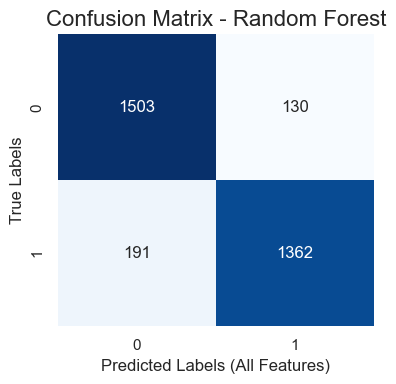

Cross-Validation Scores (All Features): [0.88461538 0.89795918 0.89481947 0.89403454 0.88854003 0.90580848
 0.90502355 0.87833595 0.88147567 0.89089482]
Average Cross-Validation Score (All Features): 0.8921507064364207


In [112]:
# Creating Random Forest model with all features
bank_RF_all = RandomForestClassifier(random_state=42)
bank_RF_all.fit(bank_X_train_all_fea_std, bank_y_train_all_fea)

bank_RF_y_pred_all = bank_RF_all.predict(bank_X_test_all_fea_std)

bank_RF_accuracy_all = accuracy_score(bank_y_test_all_fea, bank_RF_y_pred_all)
bank_RF_precision_all = precision_score(bank_y_test_all_fea, bank_RF_y_pred_all)
bank_RF_recall_all = recall_score(bank_y_test_all_fea, bank_RF_y_pred_all)
bank_RF_f1_all = f1_score(bank_y_test_all_fea, bank_RF_y_pred_all)




# Print the results
print("\033[1mRandom Forest Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {bank_RF_accuracy_all:.2f}")
print(f"Precision with all features: {bank_RF_precision_all:.2f}")
print(f"Recall with all features: {bank_RF_recall_all:.2f}")
print(f"F1-Score with all features: {bank_RF_f1_all:.2f}")

print("\n")


#confusion matrix of the models
bank_RF_conf_matrix_all = confusion_matrix(bank_y_test_all_fea, bank_RF_y_pred_all)

plt.figure(figsize=(4, 4))
sns.heatmap(bank_RF_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Random Forest', fontsize=16)



plt.tight_layout()
plt.show()



#Finding Cross validation Scores for the model

# Perform 10-fold cross-validation on the training data using all features
bank_RF_cv_scores_all_features = cross_val_score(bank_RF_all, bank_X_train_all_fea, bank_y_train_all_fea, cv=10, scoring='accuracy')


# Calculate the average cross-validation scores
bank_RF_average_cv_score_all_features = bank_RF_cv_scores_all_features.mean()

print("Cross-Validation Scores (All Features):", bank_RF_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", bank_RF_average_cv_score_all_features)

## Support Vector Machines (SVM)

Support Vector Machines (SVM) Model Performance: 


Accuracy with all features: 0.89
Precision with all features: 0.92
Recall with all features: 0.84
F1-Score with all features: 0.88




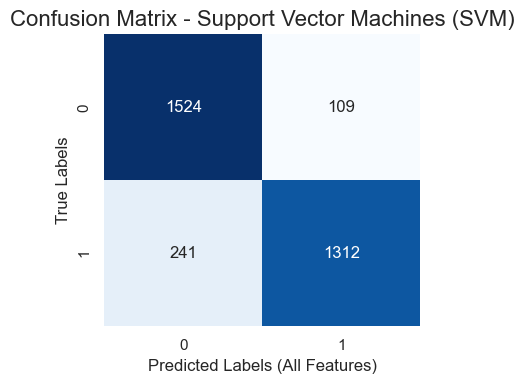

Cross-Validation Scores (All Features): [0.57613815 0.59576138 0.55102041 0.56907378 0.55416013 0.56357928
 0.58712716 0.58163265 0.57142857 0.59262166]
Average Cross-Validation Score (All Features): 0.5742543171114599


In [113]:
# Creating Support Vector Machines (SVM) model with all features
bank_SVM_all = SVC(random_state=42)
bank_SVM_all.fit(bank_X_train_all_fea_std, bank_y_train_all_fea)

bank_SVM_y_pred_all = bank_SVM_all.predict(bank_X_test_all_fea_std)

bank_SVM_accuracy_all = accuracy_score(bank_y_test_all_fea, bank_SVM_y_pred_all)
bank_SVM_precision_all = precision_score(bank_y_test_all_fea, bank_SVM_y_pred_all)
bank_SVM_recall_all = recall_score(bank_y_test_all_fea, bank_SVM_y_pred_all)
bank_SVM_f1_all = f1_score(bank_y_test_all_fea, bank_SVM_y_pred_all)



# Print the results
print("\033[1mSupport Vector Machines (SVM) Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {bank_SVM_accuracy_all:.2f}")
print(f"Precision with all features: {bank_SVM_precision_all:.2f}")
print(f"Recall with all features: {bank_SVM_recall_all:.2f}")
print(f"F1-Score with all features: {bank_SVM_f1_all:.2f}")

print("\n")


#confusion matrix of the models
bank_SVM_conf_matrix_all = confusion_matrix(bank_y_test_all_fea, bank_SVM_y_pred_all)

plt.figure(figsize=(4, 4))
sns.heatmap(bank_SVM_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Support Vector Machines (SVM)', fontsize=16)


plt.tight_layout()
plt.show()


#Finding Cross validation Scores for the model

# Perform 10-fold cross-validation on the training data using all features
bank_SVM_cv_scores_all_features = cross_val_score(bank_SVM_all, bank_X_train_all_fea, bank_y_train_all_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
bank_SVM_average_cv_score_all_features = bank_SVM_cv_scores_all_features.mean()

print("Cross-Validation Scores (All Features):", bank_SVM_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", bank_SVM_average_cv_score_all_features)


## K-Nearest Neighbors (k-NN)

K-Nearest Neighbors (k-NN) Model Performance: 


Accuracy with all features: 0.87
Precision with all features: 0.88
Recall with all features: 0.84
F1-Score with all features: 0.86




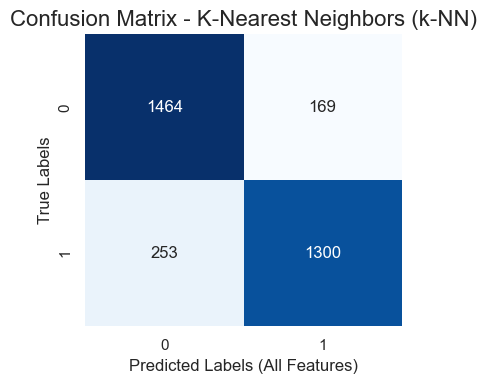

Cross-Validation Scores (All Features): [0.67817896 0.67189953 0.66169545 0.68838305 0.67032967 0.67896389
 0.67346939 0.67974882 0.69623234 0.68131868]
Average Cross-Validation Score (All Features): 0.6780219780219781


In [114]:
# Creating K-Nearest Neighbors (k-NN) model with all features

#number of neighbors is 5
bank_KNN_all = KNeighborsClassifier(n_neighbors=5) 
bank_KNN_all.fit(bank_X_train_all_fea_std, bank_y_train_all_fea)

bank_KNN_y_pred_all = bank_KNN_all.predict(bank_X_test_all_fea_std)

bank_KNN_accuracy_all = accuracy_score(bank_y_test_all_fea, bank_KNN_y_pred_all)
bank_KNN_precision_all = precision_score(bank_y_test_all_fea, bank_KNN_y_pred_all)
bank_KNN_recall_all = recall_score(bank_y_test_all_fea, bank_KNN_y_pred_all)
bank_KNN_f1_all = f1_score(bank_y_test_all_fea, bank_KNN_y_pred_all)


# Print the results
print("\033[1mK-Nearest Neighbors (k-NN) Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {bank_KNN_accuracy_all:.2f}")
print(f"Precision with all features: {bank_KNN_precision_all:.2f}")
print(f"Recall with all features: {bank_KNN_recall_all:.2f}")
print(f"F1-Score with all features: {bank_KNN_f1_all:.2f}")

print("\n")

#confusion matrix of the models
bank_KNN_conf_matrix_all = confusion_matrix(bank_y_test_all_fea, bank_KNN_y_pred_all)

plt.figure(figsize=(4, 4))
sns.heatmap(bank_KNN_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - K-Nearest Neighbors (k-NN)', fontsize=16)


plt.tight_layout()
plt.show()


#Finding Cross validation Scores for the model

# Perform 10-fold cross-validation on the training data using all features
bank_KNN_cv_scores_all_features = cross_val_score(bank_KNN_all, bank_X_train_all_fea, bank_y_train_all_fea, cv=10, scoring='accuracy')

# Calculate the average cross-validation scores
bank_KNN_average_cv_score_all_features = bank_KNN_cv_scores_all_features.mean()

print("Cross-Validation Scores (All Features):", bank_KNN_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", bank_KNN_average_cv_score_all_features)


## Gradient Boosting 

Gradient Boosting Model Performance: 


Accuracy with all features: 0.89
Precision with all features: 0.91
Recall with all features: 0.85
F1-Score with all features: 0.88




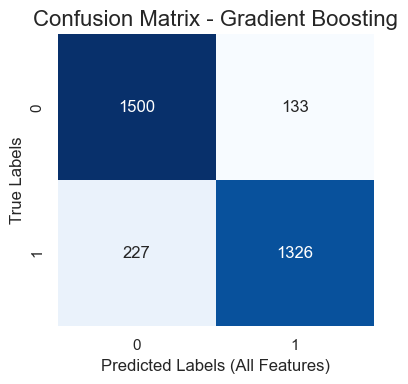

Cross-Validation Scores (All Features): [0.87362637 0.89089482 0.87833595 0.8822606  0.87755102 0.8877551
 0.89167975 0.86656201 0.8689168  0.87284144]
Average Cross-Validation Score (All Features): 0.8790423861852433


In [115]:
# Creating Gradient Boosting model with all features
bank_GB_all = GradientBoostingClassifier(random_state=42)
bank_GB_all.fit(bank_X_train_all_fea_std, bank_y_train_all_fea)

bank_GB_y_pred_all = bank_GB_all.predict(bank_X_test_all_fea_std)

bank_GB_accuracy_all = accuracy_score(bank_y_test_all_fea, bank_GB_y_pred_all)
bank_GB_precision_all = precision_score(bank_y_test_all_fea, bank_GB_y_pred_all)
bank_GB_recall_all = recall_score(bank_y_test_all_fea, bank_GB_y_pred_all)
bank_GB_f1_all = f1_score(bank_y_test_all_fea, bank_GB_y_pred_all)


# Print the results
print("\033[1mGradient Boosting Model Performance: \033[0m")
print("\n")

print(f"Accuracy with all features: {bank_GB_accuracy_all:.2f}")
print(f"Precision with all features: {bank_GB_precision_all:.2f}")
print(f"Recall with all features: {bank_GB_recall_all:.2f}")
print(f"F1-Score with all features: {bank_GB_f1_all:.2f}")

print("\n")
#confusion matrix of the model
bank_GB_conf_matrix_all = confusion_matrix(bank_y_test_all_fea, bank_GB_y_pred_all)

plt.figure(figsize=(4, 4))
sns.heatmap(bank_GB_conf_matrix_all, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels (All Features)')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Gradient Boosting', fontsize=16)

plt.tight_layout()
plt.show()



#Finding Cross validation Scores for the model

# Perform 10-fold cross-validation on the training data using all features
bank_GB_cv_scores_all_features = cross_val_score(bank_GB_all, bank_X_train_all_fea, bank_y_train_all_fea, cv=10, scoring='accuracy')


# Calculate the average cross-validation scores
bank_GB_average_cv_score_all_features = bank_GB_cv_scores_all_features.mean()

print("Cross-Validation Scores (All Features):", bank_GB_cv_scores_all_features)
print("Average Cross-Validation Score (All Features):", bank_GB_average_cv_score_all_features)


# Deep Learning Algorithms

## ANN 

In [116]:
len(bank_X_train_all_fea.columns)

13

In [117]:
# defining the Sequential model
bank_model = keras.Sequential([
    #input layer    
    keras.layers.Dense(13, input_shape=(13,), activation='relu'),
    #output layer   
    keras.layers.Dense(1, activation='sigmoid'),
])

# Compiling the model
bank_model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])

bank_model.fit(bank_X_train_all_fea_std, bank_y_train_all_fea, epochs=60)

Epoch 1/60
399/399 [==============================] - 2s 2ms/step - loss: 0.5687 - accuracy: 0.6962
Epoch 2/60
399/399 [==============================] - 1s 2ms/step - loss: 0.3765 - accuracy: 0.8343
Epoch 3/60
399/399 [==============================] - 1s 2ms/step - loss: 0.3395 - accuracy: 0.8492
Epoch 4/60
399/399 [==============================] - 1s 2ms/step - loss: 0.3213 - accuracy: 0.8567
Epoch 5/60
399/399 [==============================] - 1s 2ms/step - loss: 0.3101 - accuracy: 0.8632
Epoch 6/60
399/399 [==============================] - 1s 2ms/step - loss: 0.3031 - accuracy: 0.8656
Epoch 7/60
399/399 [==============================] - 1s 2ms/step - loss: 0.2976 - accuracy: 0.8691
Epoch 8/60
399/399 [==============================] - 1s 2ms/step - loss: 0.2936 - accuracy: 0.8706
Epoch 9/60
399/399 [==============================] - 1s 2ms/step - loss: 0.2903 - accuracy: 0.8723
Epoch 10/60
399/399 [==============================] - 1s 3ms/step - loss: 0.2878 - accuracy: 0.8727

In [118]:
bank_ANN_eval_results = bank_model.evaluate(bank_X_train_all_fea_std,bank_y_train_all_fea)
accuracy_index = 1
bank_ANN_accuracy = bank_ANN_eval_results[accuracy_index]
print(f"Accuracy: {bank_ANN_accuracy:.2f}")

399/399 [==============================] - 1s 2ms/step - loss: 0.2670 - accuracy: 0.8815
Accuracy: 0.88


In [119]:
bank_y_pred = bank_model.predict(bank_X_test_all_fea_std)
bank_y_pred_binary = (bank_y_pred > 0.5)

bank_ANN_precision = precision_score(bank_y_test_all_fea, bank_y_pred_binary)
bank_ANN_recall = recall_score(bank_y_test_all_fea, bank_y_pred_binary)
bank_ANN_f1 = f1_score(bank_y_test_all_fea, bank_y_pred_binary)

print("Precision:", bank_ANN_precision)
print("Recall:", bank_ANN_recall)
print("F1-score:", bank_ANN_f1)

100/100 [==============================] - 0s 2ms/step
Precision: 0.9150552486187845
Recall: 0.8531873792659369
F1-score: 0.8830389870043318


### CNN 

In [120]:
# Create a Sequential model
bank_cnn_model = Sequential()

# Add Convolutional layer with max pooling
bank_cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(bank_X_train_all_fea_std.shape[1], 1)))
bank_cnn_model.add(MaxPooling1D(pool_size=2))

# Add a Flatten layer
bank_cnn_model.add(Flatten())

# Add fully connected layers
bank_cnn_model.add(Dense(46, activation='relu'))
bank_cnn_model.add(Dense(1, activation='sigmoid'))  # Binary classification output

# Compile the model
bank_cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

bank_cnn_model.fit(bank_X_train_all_fea_std, bank_y_train_all_fea, epochs=55)

# model evalution
loss, accuracy = bank_cnn_model.evaluate(bank_X_test_all_fea_std, bank_y_test_all_fea)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Epoch 1/55
399/399 [==============================] - 2s 4ms/step - loss: 0.3774 - accuracy: 0.8272
Epoch 2/55
399/399 [==============================] - 2s 4ms/step - loss: 0.3069 - accuracy: 0.8650
Epoch 3/55
399/399 [==============================] - 2s 4ms/step - loss: 0.2935 - accuracy: 0.8675
Epoch 4/55
399/399 [==============================] - 2s 5ms/step - loss: 0.2944 - accuracy: 0.8707
Epoch 5/55
399/399 [==============================] - 2s 4ms/step - loss: 0.2885 - accuracy: 0.8730
Epoch 6/55
399/399 [==============================] - 2s 4ms/step - loss: 0.2872 - accuracy: 0.8721
Epoch 7/55
399/399 [==============================] - 2s 4ms/step - loss: 0.2815 - accuracy: 0.8766
Epoch 8/55
399/399 [==============================] - 2s 4ms/step - loss: 0.2792 - accuracy: 0.8758
Epoch 9/55
399/399 [==============================] - 2s 4ms/step - loss: 0.2815 - accuracy: 0.8753
Epoch 10/55
399/399 [==============================] - 2s 4ms/step - loss: 0.2781 - accuracy: 0.8793

In [121]:
bank_CNN_eval_results = bank_cnn_model.evaluate(bank_X_train_all_fea_std,bank_y_train_all_fea)
accuracy_index = 1
bank_CNN_accuracy = bank_CNN_eval_results[accuracy_index]
print(f"Accuracy: {bank_CNN_accuracy:.2f}")

399/399 [==============================] - 2s 5ms/step - loss: 0.2348 - accuracy: 0.8982
Accuracy: 0.90


In [122]:
bank_y_pred_cnn = bank_cnn_model.predict(bank_X_test_all_fea_std)
bank_y_pred_binary_cnn = (bank_y_pred_cnn > 0.5)

bank_CNN_precision = precision_score(bank_y_test_all_fea, bank_y_pred_binary_cnn)
bank_CNN_recall = recall_score(bank_y_test_all_fea, bank_y_pred_binary_cnn)
bank_CNN_f1 = f1_score(bank_y_test_all_fea, bank_y_pred_binary_cnn)

print("Precision:", bank_CNN_precision)
print("Recall:", bank_CNN_recall)
print("F1-score:", bank_CNN_f1)

100/100 [==============================] - 1s 4ms/step
Precision: 0.9138290479499652
Recall: 0.8467482292337412
F1-score: 0.8790106951871659


### Performance Metrics Comparison between best Machine learning and Deep Learning Models 

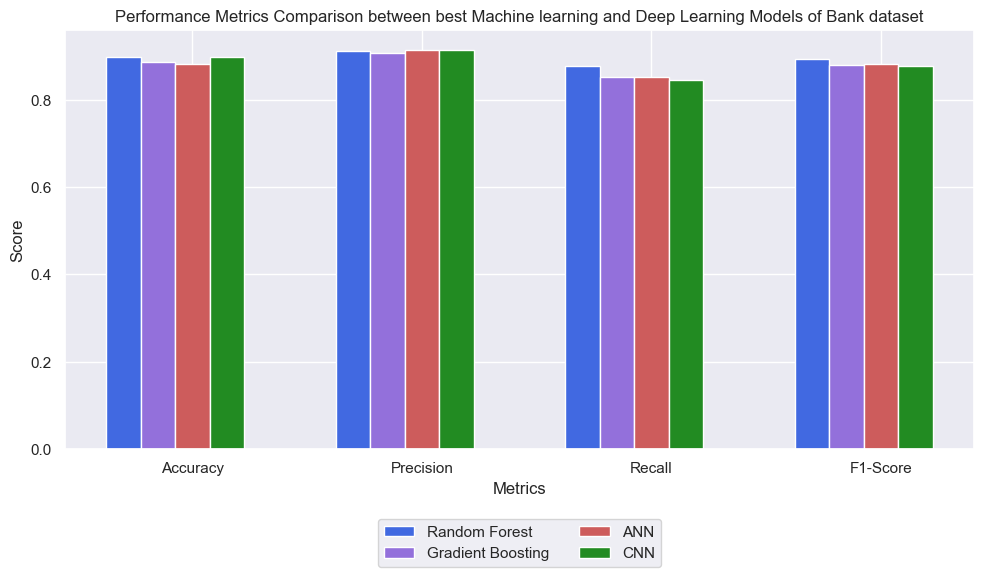

In [123]:
bank_classifiers = ["Random Forest", "Gradient Boosting", "ANN", "CNN"]
bank_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

bank_Random_Forest = [bank_RF_accuracy_all, bank_RF_precision_all, bank_RF_recall_all, bank_RF_f1_all]
bank_Gradient_Boosting = [bank_GB_accuracy_all, bank_GB_precision_all, bank_GB_recall_all, bank_GB_f1_all]
bank_ANN = [bank_ANN_accuracy, bank_ANN_precision, bank_ANN_recall, bank_ANN_f1]
bank_CNN = [bank_CNN_accuracy, bank_CNN_precision, bank_CNN_recall, bank_CNN_f1]

bank_data = [
    bank_Random_Forest, bank_Gradient_Boosting, bank_ANN, bank_CNN
]

bank_num_classifiers = len(bank_classifiers)
bank_num_metrics = len(bank_metrics)
bank_bar_width = 0.15  
bank_index = np.arange(bank_num_metrics)

# Creating a list of colors
blue_colors = ['#4169E1', '#9370DB', '#CD5C5C', '#228B22']

fig, ax = plt.subplots(figsize=(10, 6))

for i, classifier in enumerate(bank_classifiers):
    bank_classifier_values = bank_data[i]
    ax.bar(bank_index + i * bank_bar_width, bank_classifier_values, bank_bar_width, color=blue_colors[i], label=classifier)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics Comparison between best Machine learning and Deep Learning Models of Bank dataset')
ax.set_xticks(bank_index + (bank_num_classifiers / 2) * bank_bar_width)
ax.set_xticklabels(bank_metrics)

# Placing the legend (models name) at the bottom in two lines
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()